# Mini π₀.₅ Heterogeneous Pretraining Reproduction

This notebook reproduces the core heterogeneous pretraining idea from
Physical Intelligence's π₀.₅ at small scale.

## Training mixture

1. **ALOHA** — robot action prediction
2. **DROID** — second robot embodiment / action space
3. **COCO** — image captioning
4. **VQAv2** — visual question answering

The common objective is autoregressive next-token prediction:

    multimodal context
            ↓
    shared transformer
            ↓
    token targets
            ↓
    cross-entropy

Robot actions are converted into FAST tokens. Web tasks produce ordinary
text tokens. Both occupy the same language-model vocabulary and use the
same autoregressive loss machinery.

## Initial model

- width: 256
- depth: 4
- MLP dimension: 1024
- ~69.7M parameters
- fully trainable
- batch size initially 1

## Phase 1

Before constructing the heterogeneous sampler, inspect and verify the raw
representation of each data source, beginning with ALOHA and DROID.

In [1]:
# Cell 1 — environment + OpenPI component check

import os

# Avoid JAX eagerly reserving essentially all GPU memory.
# This matters later when we inspect data and train inside the same notebook.
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

from pathlib import Path
import sys

import numpy as np
import jax

from openpi import transforms
from openpi.models import tokenizer
from openpi.policies import aloha_policy
from openpi.policies import droid_policy
from openpi.training import config as training_config


print("========== ENVIRONMENT ==========")

print("Python:", sys.version.split()[0])
print("Working directory:", Path.cwd())

print("\nJAX devices:")
for device in jax.devices():
    print(" ", device)


print("\n========== OPENPI SOURCE ==========")

print("transforms.py:")
print(" ", Path(transforms.__file__).resolve())

print("tokenizer.py:")
print(" ", Path(tokenizer.__file__).resolve())

print("aloha_policy.py:")
print(" ", Path(aloha_policy.__file__).resolve())

print("droid_policy.py:")
print(" ", Path(droid_policy.__file__).resolve())

print("training/config.py:")
print(" ", Path(training_config.__file__).resolve())


print("\n========== REQUIRED COMPONENTS ==========")

required = {
    "Normalize": hasattr(transforms, "Normalize"),
    "PadStatesAndActions": hasattr(transforms, "PadStatesAndActions"),
    "TokenizeFASTInputs": hasattr(transforms, "TokenizeFASTInputs"),
    "FASTTokenizer": hasattr(tokenizer, "FASTTokenizer"),
    "AlohaInputs": hasattr(aloha_policy, "AlohaInputs"),
    "DroidInputs": hasattr(droid_policy, "DroidInputs"),
    "LeRobotDROIDDataConfig": hasattr(
        training_config,
        "LeRobotDROIDDataConfig",
    ),
}

for name, present in required.items():
    print(f"{name:24s}: {present}")

assert all(required.values()), (
    "At least one OpenPI component expected by this notebook "
    "is missing from the current checkout."
)

print("\nOpenPI component check passed.")

========== ENVIRONMENT ==========
Python: 3.11.16
Working directory: /home/osx/openpi

JAX devices:
  cuda:0

========== OPENPI SOURCE ==========
transforms.py:
  /home/osx/openpi/src/openpi/transforms.py
tokenizer.py:
  /home/osx/openpi/src/openpi/models/tokenizer.py
aloha_policy.py:
  /home/osx/openpi/src/openpi/policies/aloha_policy.py
droid_policy.py:
  /home/osx/openpi/src/openpi/policies/droid_policy.py
training/config.py:
  /home/osx/openpi/src/openpi/training/config.py

========== REQUIRED COMPONENTS ==========
Normalize               : True
PadStatesAndActions     : True
TokenizeFASTInputs      : True
FASTTokenizer           : True
AlohaInputs             : True
DroidInputs             : True
LeRobotDROIDDataConfig  : True

OpenPI component check passed.


In [2]:
# Cell 2 — acquire + verify ALL heterogeneous pretraining datasets

from pathlib import Path
import json
import shutil
import subprocess

from datasets import load_dataset, load_from_disk
from huggingface_hub import snapshot_download


# ============================================================
# Experiment dataset configuration
# ============================================================

DATA_ROOT = Path("/home/osx/openpi/data/pi05_heterogeneous")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

# ---------------- Robot source 1: ALOHA ----------------

ALOHA_REPO = "lerobot/aloha_static_screw_driver"

# ---------------- Robot source 2: DROID ----------------

# Keep the raw DROID data we already downloaded.
DROID_RAW_DIR = Path("/home/osx/openpi/data/droid_small")
DROID_EPISODE_DIR = DROID_RAW_DIR / "2023-12-04"
DROID_ANNOTATIONS = (
    DROID_RAW_DIR / "aggregated-annotations-030724.json"
)

DROID_CONVERTER = Path(
    "/home/osx/openpi/examples/droid/"
    "convert_droid_data_to_lerobot.py"
)

# ---------------- Web task 1: COCO captioning ----------------

COCO_REPO = "jxie/coco_captions"

# COCO has ~5 captions per image in this representation.
# Grab enough rows to later construct ~2k UNIQUE training
# images + held-out images without downloading the entire corpus.
COCO_DOWNLOAD_ROWS = 12_000

COCO_DIR = DATA_ROOT / "coco_subset"

# ---------------- Web task 2: VQAv2 ----------------

VQA_REPO = "merve/vqav2-small"

# Later:
# ~2,000 train
# ~250 validation
# plus a little extra headroom.
VQA_DOWNLOAD_ROWS = 2_500

VQA_DIR = DATA_ROOT / "vqav2_subset"


print("============================================================")
print(" π0.5 HETEROGENEOUS DATASET SETUP")
print("============================================================")


# ============================================================
# 1. ALOHA
# ============================================================

print("\n[1/4] ALOHA")

# snapshot_download uses the HF cache.
# If we already downloaded this during the previous notebook,
# the existing cached files are reused instead of duplicated.
ALOHA_DIR = Path(
    snapshot_download(
        repo_id=ALOHA_REPO,
        repo_type="dataset",
    )
)

aloha_parquet = list(ALOHA_DIR.rglob("*.parquet"))
aloha_videos = list(ALOHA_DIR.rglob("*.mp4"))

print("repository:       ", ALOHA_REPO)
print("local path:       ", ALOHA_DIR)
print("parquet files:    ", len(aloha_parquet))
print("video files:      ", len(aloha_videos))

assert aloha_parquet, "ALOHA parquet data was not found."
assert aloha_videos, "ALOHA videos were not found."

print("status:            READY")


# ============================================================
# 2. DROID
# ============================================================

print("\n[2/4] DROID")

DROID_RAW_DIR.mkdir(parents=True, exist_ok=True)

trajectory_files = sorted(
    DROID_RAW_DIR.rglob("trajectory.h5")
)

mp4_dirs = sorted(
    DROID_RAW_DIR.rglob("recordings/MP4")
)

droid_complete = (
    len(trajectory_files) >= 30
    and len(mp4_dirs) >= 30
    and DROID_ANNOTATIONS.exists()
)

if not droid_complete:

    print("DROID subset incomplete — downloading missing data...")

    gsutil = shutil.which("gsutil")
    uvx = shutil.which("uvx")

    if gsutil:
        gsutil_cmd = [gsutil]

    elif uvx:
        gsutil_cmd = [uvx, "gsutil"]

    else:
        raise RuntimeError(
            "Need either gsutil or uvx to download DROID."
        )

    if len(trajectory_files) == 0:

        subprocess.run(
            gsutil_cmd
            + [
                "-m",
                "cp",
                "-r",
                "gs://gresearch/robotics/droid_raw/1.0.1/"
                "IRIS/success/2023-12-04",
                str(DROID_RAW_DIR),
            ],
            check=True,
        )

    if not DROID_ANNOTATIONS.exists():

        subprocess.run(
            gsutil_cmd
            + [
                "-m",
                "cp",
                "gs://gresearch/robotics/droid_raw/1.0.1/"
                "aggregated-annotations-030724.json",
                str(DROID_RAW_DIR),
            ],
            check=True,
        )


# Recheck after possible download.
trajectory_files = sorted(
    DROID_RAW_DIR.rglob("trajectory.h5")
)

mp4_dirs = sorted(
    DROID_RAW_DIR.rglob("recordings/MP4")
)

print("local path:       ", DROID_RAW_DIR)
print("trajectories:     ", len(trajectory_files))
print("MP4 directories:  ", len(mp4_dirs))
print("annotations:      ", DROID_ANNOTATIONS.exists())

assert len(trajectory_files) >= 30
assert len(mp4_dirs) >= 30
assert DROID_ANNOTATIONS.exists()
assert DROID_CONVERTER.exists()

print("status:            READY")


# ============================================================
# 3. COCO CAPTIONING
# ============================================================

print("\n[3/4] COCO CAPTIONING")

if (COCO_DIR / "state.json").exists():

    print("Local subset already exists — loading it.")

    coco = load_from_disk(str(COCO_DIR))

else:

    print(
        f"Downloading first {COCO_DOWNLOAD_ROWS:,} "
        "COCO caption rows..."
    )

    coco = load_dataset(
        COCO_REPO,
        split=f"train[:{COCO_DOWNLOAD_ROWS}]",
    )

    coco.save_to_disk(str(COCO_DIR))


print("repository:       ", COCO_REPO)
print("local path:       ", COCO_DIR)
print("rows:             ", len(coco))
print("columns:          ", coco.column_names)

assert len(coco) >= COCO_DOWNLOAD_ROWS
assert "image" in coco.column_names
assert "caption" in coco.column_names
assert "cocoid" in coco.column_names

unique_coco_images = len(set(coco["cocoid"]))

print("unique images:    ", unique_coco_images)

assert unique_coco_images >= 2_250, (
    "Not enough unique COCO images for our planned split."
)

print("status:            READY")


# ============================================================
# 4. VQAv2
# ============================================================

print("\n[4/4] VQAv2")

if (VQA_DIR / "state.json").exists():

    print("Local subset already exists — loading it.")

    vqa = load_from_disk(str(VQA_DIR))

else:

    print(
        f"Downloading first {VQA_DOWNLOAD_ROWS:,} "
        "VQAv2 examples..."
    )

    vqa = load_dataset(
        VQA_REPO,
        split=f"validation[:{VQA_DOWNLOAD_ROWS}]",
    )

    vqa.save_to_disk(str(VQA_DIR))


print("repository:       ", VQA_REPO)
print("local path:       ", VQA_DIR)
print("rows:             ", len(vqa))
print("columns:          ", vqa.column_names)

assert len(vqa) >= 2_250
assert "image" in vqa.column_names
assert "question" in vqa.column_names
assert "multiple_choice_answer" in vqa.column_names

print("status:            READY")


# ============================================================
# Save experiment dataset manifest
# ============================================================

manifest = {
    "aloha": {
        "repo": ALOHA_REPO,
        "path": str(ALOHA_DIR),
    },
    "droid": {
        "path": str(DROID_RAW_DIR),
        "trajectories": len(trajectory_files),
    },
    "coco": {
        "repo": COCO_REPO,
        "path": str(COCO_DIR),
        "rows": len(coco),
        "unique_images": unique_coco_images,
    },
    "vqav2": {
        "repo": VQA_REPO,
        "path": str(VQA_DIR),
        "rows": len(vqa),
    },
}

MANIFEST_PATH = DATA_ROOT / "dataset_manifest.json"

with MANIFEST_PATH.open("w") as f:
    json.dump(manifest, f, indent=2)


# ============================================================
# Final summary
# ============================================================

print("\n============================================================")
print(" DATASET MIXTURE READY")
print("============================================================")

print(f"""
ALOHA
  robot embodiment 1
  location: {ALOHA_DIR}

DROID
  robot embodiment 2
  trajectories: {len(trajectory_files)}

COCO
  captioning
  rows downloaded: {len(coco)}
  unique images:   {unique_coco_images}

VQAv2
  visual question answering
  rows downloaded: {len(vqa)}

Manifest:
  {MANIFEST_PATH}
""")

 π0.5 HETEROGENEOUS DATASET SETUP

[1/4] ALOHA


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

repository:        lerobot/aloha_static_screw_driver
local path:        /home/osx/.cache/huggingface/hub/datasets--lerobot--aloha_static_screw_driver/snapshots/21eead16760a8d94d449cadf4bc438b322ab528d
parquet files:     3
video files:       4
status:            READY

[2/4] DROID
local path:        /home/osx/openpi/data/droid_small
trajectories:      30
MP4 directories:   30
annotations:       True
status:            READY

[3/4] COCO CAPTIONING
Local subset already exists — loading it.
repository:        jxie/coco_captions
local path:        /home/osx/openpi/data/pi05_heterogeneous/coco_subset
rows:              12000
columns:           ['image', 'filename', 'cocoid', 'caption']
unique images:     2398
status:            READY

[4/4] VQAv2


README.md:   0%|          | 0.00/403 [00:00<?, ?B/s]

data/validation-00000-of-00007.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

...

data/validation-00005-of-00007.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

data/validation-00006-of-00007.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/21435 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

repository:        merve/vqav2-small
local path:        /home/osx/openpi/data/pi05_heterogeneous/vqav2_subset
rows:              2500
columns:           ['multiple_choice_answer', 'question', 'image']
status:            READY

 DATASET MIXTURE READY

ALOHA
  robot embodiment 1
  location: /home/osx/.cache/huggingface/hub/datasets--lerobot--aloha_static_screw_driver/snapshots/21eead16760a8d94d449cadf4bc438b322ab528d

DROID
  robot embodiment 2
  trajectories: 30

COCO
  captioning
  rows downloaded: 12000
  unique images:   2398

VQAv2
  visual question answering
  rows downloaded: 2500

Manifest:
  /home/osx/openpi/data/pi05_heterogeneous/dataset_manifest.json



========== ALOHA DATASET ==========
repository:        lerobot/aloha_static_screw_driver
loaded episodes:   [0]
frames loaded:     400
fps:               50

========== RAW LEROBOT EXAMPLE ==========
keys:
observation.images.cam_high           shape=(3, 480, 640)      dtype=torch.float32
observation.images.cam_left_wrist     shape=(3, 480, 640)      dtype=torch.float32
observation.images.cam_low            shape=(3, 480, 640)      dtype=torch.float32
observation.images.cam_right_wrist    shape=(3, 480, 640)      dtype=torch.float32
observation.state                     shape=(14,)              dtype=torch.float32
observation.effort                    shape=(14,)              dtype=torch.float32
action                                shape=(50, 14)           dtype=torch.float32
episode_index                         shape=()                 dtype=torch.int64
frame_index                           shape=()                 dtype=torch.int64
timestamp                             shape=()     

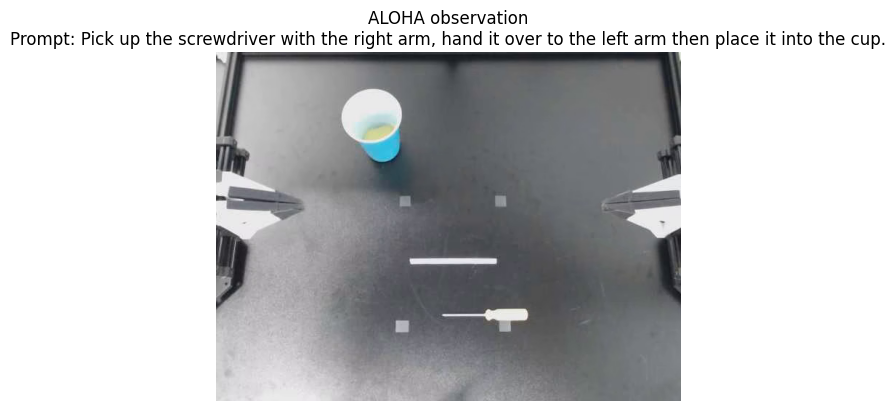


========== π0.5 PRETRAINING INTERPRETATION ==========

INPUT
-----
image:
    (480, 640, 3)

robot state:
    (14,)

language:
    'Pick up the screwdriver with the right arm, hand it over to the left arm then place it into the cup.'

TARGET
------
future robot action chunk:
    (50, 14)

NEXT STAGES
-----------
dataset-specific q01/q99 normalization
        ↓
FAST action tokenization
        ↓
autoregressive token targets
        ↓
next-token cross entropy



In [7]:
# Cell 3 — inspect ALOHA as a π0.5 pretraining source

import numpy as np
import matplotlib.pyplot as plt

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset

from openpi import transforms
from openpi.policies import aloha_policy


# ============================================================
# Helpers
# ============================================================

def as_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def describe(name, value):
    if hasattr(value, "shape"):
        print(
            f"{name:38s}"
            f"shape={tuple(value.shape)!s:18s} "
            f"dtype={value.dtype}"
        )
    else:
        print(f"{name:38s}{value!r}")


# ============================================================
# Load ONE ALOHA episode for inspection
# ============================================================

print("========== ALOHA DATASET ==========")

# The public dataset is 50 Hz.
# We only need one episode in this cell to inspect the
# representation, so explicitly load episode 0.
FPS = 50
ACTION_HORIZON = 50

action_times = [
    i / FPS
    for i in range(ACTION_HORIZON)
]

aloha = LeRobotDataset(
    repo_id=ALOHA_REPO,
    root=ALOHA_DIR,
    episodes=[0],
    delta_timestamps={
        "action": action_times,
    },
)

print("repository:       ", ALOHA_REPO)
print("loaded episodes:  ", [0])
print("frames loaded:    ", len(aloha))
print("fps:              ", FPS)

sample = aloha[0]


# ============================================================
# Inspect raw LeRobot example
# ============================================================

print("\n========== RAW LEROBOT EXAMPLE ==========")

print("keys:")

for key in sample.keys():
    value = sample[key]

    if hasattr(value, "shape"):
        describe(key, value)

    elif isinstance(value, (str, int, float)):
        describe(key, value)


# ============================================================
# Pull out the important π0.5 quantities
# ============================================================

state = as_numpy(
    sample["observation.state"]
)

actions = as_numpy(
    sample["action"]
)

image_keys = sorted(
    key
    for key in sample.keys()
    if key.startswith("observation.images.")
)

print("\n========== ROBOT STATE ==========")

print("state shape:", state.shape)
print("state:")
print(state)


print("\n========== ACTION TARGET ==========")

print("action chunk shape:", actions.shape)

print("\nfirst action:")
print(actions[0])

print("\nlast action:")
print(actions[-1])


print("\n========== CAMERA INPUTS ==========")

for key in image_keys:
    image = as_numpy(sample[key])
    describe(key, image)


# ============================================================
# Language/task
# ============================================================

if "task" in sample:
    prompt = sample["task"]

elif "prompt" in sample:
    prompt = sample["prompt"]

else:
    # Known task for this dataset.
    prompt = "tighten the screw"

print("\n========== LANGUAGE INPUT ==========")
print("prompt:", prompt)


# ============================================================
# Repack into the schema expected by OpenPI's ALOHA adapter
#
# This dataset already uses the native ALOHA camera names:
#
# observation.images.cam_high
# observation.images.cam_low
# observation.images.cam_left_wrist
# observation.images.cam_right_wrist
#
# AlohaInputs expects those names without the
# "observation.images." prefix.
# ============================================================

camera_map = {
    "cam_high": "observation.images.cam_high",
    "cam_low": "observation.images.cam_low",
    "cam_left_wrist": "observation.images.cam_left_wrist",
    "cam_right_wrist": "observation.images.cam_right_wrist",
}

for openpi_name, dataset_key in camera_map.items():
    assert dataset_key in sample, (
        f"Missing {dataset_key}. "
        f"Available image keys: {image_keys}"
    )

aloha_input = {
    "images": {
        openpi_name: as_numpy(sample[dataset_key])
        for openpi_name, dataset_key in camera_map.items()
    },
    "state": state,
    "actions": actions,
    "prompt": prompt,
}

print("\nRepacked ALOHA cameras:")
for name, image in aloha_input["images"].items():
    print(f"{name:24s}", image.shape)

# ============================================================
# Apply OpenPI's embodiment-specific ALOHA conversion
#
# This:
#   - converts images to HWC uint8
#   - converts ALOHA joint convention → PI convention
#   - converts ALOHA gripper representation → PI representation
#   - gives the cameras the common OpenPI names
# ============================================================

aloha_adapter = aloha_policy.AlohaInputs(
    adapt_to_pi=True
)

adapted = aloha_adapter(aloha_input)


print("\n========== AFTER AlohaInputs ==========")

print("state shape:  ", adapted["state"].shape)
print("actions shape:", adapted["actions"].shape)
print("prompt:       ", adapted["prompt"])

print("\nOpenPI image slots:")

for key, image in adapted["image"].items():
    print(
        f"{key:24s}",
        image.shape,
        image.dtype,
        "mask =",
        bool(adapted["image_mask"][key]),
    )


# ============================================================
# Apply the ALOHA action convention used by OpenPI
#
# 6 left-arm joints  -> delta
# left gripper       -> absolute
# 6 right-arm joints -> delta
# right gripper      -> absolute
# ============================================================

delta_mask = transforms.make_bool_mask(
    6, -1,
    6, -1,
)

delta_transform = transforms.DeltaActions(
    delta_mask
)

delta_example = delta_transform(
    {
        "state": adapted["state"].copy(),
        "actions": adapted["actions"].copy(),
    }
)

delta_actions = delta_example["actions"]


print("\n========== AFTER DELTA-ACTION TRANSFORM ==========")

print("shape:", delta_actions.shape)

print("\nfirst transformed action:")
print(delta_actions[0])

delta_mask_np = np.asarray(delta_mask, dtype=bool)

print("\nDelta mask:")
print(delta_mask_np.astype(int))

print(
    "\nDelta dimensions:",
    int(delta_mask_np.sum()),
)

print(
    "Absolute dimensions:",
    int((~delta_mask_np).sum()),
)


# ============================================================
# Visualize the actual observation
# ============================================================

image = adapted["image"]["base_0_rgb"]

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"ALOHA observation\nPrompt: {prompt}")
plt.axis("off")
plt.show()


# ============================================================
# What this training example means
# ============================================================

print("\n========== π0.5 PRETRAINING INTERPRETATION ==========")

print(f"""
INPUT
-----
image:
    {adapted["image"]["base_0_rgb"].shape}

robot state:
    {adapted["state"].shape}

language:
    {prompt!r}

TARGET
------
future robot action chunk:
    {delta_actions.shape}

NEXT STAGES
-----------
dataset-specific q01/q99 normalization
        ↓
FAST action tokenization
        ↓
autoregressive token targets
        ↓
next-token cross entropy
""")

========== DROID DATASET ==========
episode:
  Mon_Dec__4_15:44:25_2023

episode id:
  IRIS+7dfa2da3+2023-12-04-15h-44m-25s

trajectory length:
  227

language instruction:
  Remove the glass lid from the silver pot

========== RAW DROID EXAMPLE ==========

Camera IDs:
wrist:    ['19824535']
exterior: ['23404442', '29838012']

========== ROBOT STATE ==========
joint positions:   (7,)
gripper position:  (1,)
combined state:    (8,)

state:
[-0.130916   -0.70164484 -0.20237908 -2.4456604  -0.15472902  1.8200938
 -0.21564071  0.        ]

========== ACTION TARGET ==========
action chunk shape: (50, 8)

first action:
[ 9.9125842e-04  3.8871155e-03  1.6174786e-03  1.3114939e-02
  2.6102166e-03 -1.4404342e-02  2.4927529e-05  0.0000000e+00]

last action:
[-0.05166788  0.6223093   0.06250299  0.4555995  -0.20744115  0.1175129
 -0.40061694  0.        ]

========== CAMERA INPUTS ==========
exterior_image_1: (180, 320, 3) uint8
exterior_image_2: (180, 320, 3) uint8
wrist_image: (180, 320, 3) uint

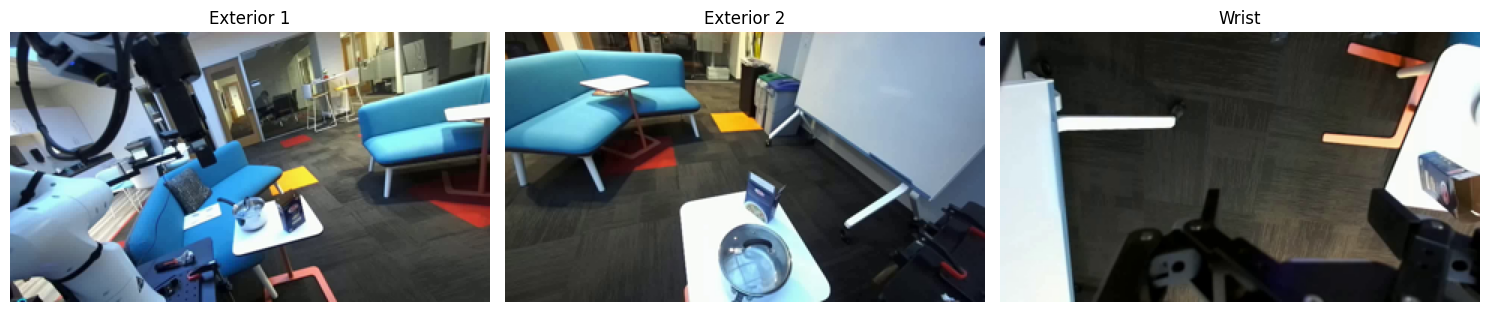


========== π0.5 PRETRAINING INTERPRETATION ==========

INPUT
-----
robot images:
    exterior 1: (180, 320, 3)
    exterior 2: (180, 320, 3)
    wrist:      (180, 320, 3)

robot state:
    (8,)

language:
    'Remove the glass lid from the silver pot'

TARGET
------
future robot action chunk:
    (50, 8)

action semantics:
    7 joint velocities
    + 1 gripper position

NEXT STAGES
-----------
DROID-specific q01/q99 normalization
        ↓
pad 8-D → common robot dimension
        ↓
FAST action tokenization
        ↓
autoregressive token targets
        ↓
next-token cross entropy



In [8]:
# Cell 4 — inspect DROID as a π0.5 pretraining source

import importlib.util
import json

import numpy as np
import matplotlib.pyplot as plt

from openpi.models import model as openpi_model
from openpi.policies import droid_policy


# ============================================================
# Load OpenPI's actual DROID conversion helpers
# ============================================================

spec = importlib.util.spec_from_file_location(
    "openpi_droid_converter",
    DROID_CONVERTER,
)

droid_converter = importlib.util.module_from_spec(spec)
spec.loader.exec_module(droid_converter)


# ============================================================
# Pick one deterministic DROID episode
# ============================================================

episode_paths = sorted(
    DROID_RAW_DIR.rglob("trajectory.h5")
)

episode_path = episode_paths[0]

recording_dir = (
    episode_path.parent
    / "recordings"
    / "MP4"
)

metadata_path = next(
    episode_path.parent.glob("metadata_*.json")
)

episode_id = (
    metadata_path.name
    .split(".")[0]
    .split("_")[-1]
)


# ============================================================
# Get the language instruction
# ============================================================

with DROID_ANNOTATIONS.open() as f:
    language_annotations = json.load(f)

annotation = language_annotations.get(
    episode_id,
    {"language_instruction1": "Do something"},
)

prompt = annotation["language_instruction1"]


# ============================================================
# Load the complete raw trajectory
#
# We need contiguous timesteps because our target is a
# 50-step future action chunk.
# ============================================================

trajectory = droid_converter.load_trajectory(
    filepath=str(episode_path),
    recording_folderpath=str(recording_dir),
)

print("========== DROID DATASET ==========")

print("episode:")
print(" ", episode_path.parent.name)

print("\nepisode id:")
print(" ", episode_id)

print("\ntrajectory length:")
print(" ", len(trajectory))

print("\nlanguage instruction:")
print(" ", prompt)


# ============================================================
# Construct one 50-step training example
# ============================================================

ACTION_HORIZON = 50

assert len(trajectory) >= ACTION_HORIZON, (
    f"Episode only has {len(trajectory)} steps."
)

chunk = trajectory[:ACTION_HORIZON]
step0 = chunk[0]


# ============================================================
# Camera identities
# ============================================================

camera_types = step0["observation"]["camera_type"]

wrist_ids = [
    camera_id
    for camera_id, camera_type in camera_types.items()
    if camera_type == 0
]

exterior_ids = [
    camera_id
    for camera_id, camera_type in camera_types.items()
    if camera_type != 0
]

assert len(wrist_ids) >= 1
assert len(exterior_ids) >= 2


# ============================================================
# Convert camera images exactly like OpenPI's DROID converter
#
# Raw DROID video is BGR.
# OpenPI:
#   BGR -> RGB
#   resize -> (320, 180)
# ============================================================

exterior_image_1 = droid_converter.resize_image(
    step0["observation"]["image"][exterior_ids[0]][..., ::-1],
    (320, 180),
)

exterior_image_2 = droid_converter.resize_image(
    step0["observation"]["image"][exterior_ids[1]][..., ::-1],
    (320, 180),
)

wrist_image = droid_converter.resize_image(
    step0["observation"]["image"][wrist_ids[0]][..., ::-1],
    (320, 180),
)


# ============================================================
# Construct DROID proprioceptive state
#
# 7 joint positions
# +
# 1 gripper position
# =
# 8-D state
# ============================================================

joint_position = np.asarray(
    step0["observation"]["robot_state"]["joint_positions"],
    dtype=np.float32,
)

gripper_position = np.asarray(
    [
        step0["observation"]["robot_state"]["gripper_position"]
    ],
    dtype=np.float32,
).reshape(-1)

state_8d = np.concatenate(
    [
        joint_position,
        gripper_position,
    ]
)


# ============================================================
# Construct the 50-step action target
#
# OpenPI's DROID converter uses:
#
# 7 joint velocities
# +
# 1 gripper position
# =
# 8-D action
# ============================================================

actions_8d = np.stack(
    [
        np.concatenate(
            [
                np.asarray(
                    step["action"]["joint_velocity"],
                    dtype=np.float32,
                ),
                np.asarray(
                    [
                        step["action"]["gripper_position"]
                    ],
                    dtype=np.float32,
                ).reshape(-1),
            ]
        )
        for step in chunk
    ]
)


# ============================================================
# Inspect raw representation
# ============================================================

print("\n========== RAW DROID EXAMPLE ==========")

print("\nCamera IDs:")
print("wrist:   ", wrist_ids)
print("exterior:", exterior_ids)

print("\n========== ROBOT STATE ==========")

print("joint positions:  ", joint_position.shape)
print("gripper position: ", gripper_position.shape)
print("combined state:   ", state_8d.shape)

print("\nstate:")
print(state_8d)


print("\n========== ACTION TARGET ==========")

print("action chunk shape:", actions_8d.shape)

print("\nfirst action:")
print(actions_8d[0])

print("\nlast action:")
print(actions_8d[-1])


print("\n========== CAMERA INPUTS ==========")

print(
    "exterior_image_1:",
    exterior_image_1.shape,
    exterior_image_1.dtype,
)

print(
    "exterior_image_2:",
    exterior_image_2.shape,
    exterior_image_2.dtype,
)

print(
    "wrist_image:",
    wrist_image.shape,
    wrist_image.dtype,
)


# ============================================================
# Repack into the format consumed by DroidInputs
# ============================================================

droid_input = {
    "observation/exterior_image_1_left":
        exterior_image_1,

    "observation/exterior_image_2_left":
        exterior_image_2,

    "observation/wrist_image_left":
        wrist_image,

    "observation/joint_position":
        joint_position,

    "observation/gripper_position":
        gripper_position,

    "actions":
        actions_8d,

    "prompt":
        prompt,
}


# ============================================================
# Apply OpenPI's actual DROID model adapter
# ============================================================

droid_adapter = droid_policy.DroidInputs(
    model_type=openpi_model.ModelType.PI0_FAST
)

adapted = droid_adapter(
    droid_input
)


print("\n========== AFTER DroidInputs ==========")

print(
    "state shape:  ",
    adapted["state"].shape,
)

print(
    "actions shape:",
    adapted["actions"].shape,
)

print(
    "prompt:       ",
    adapted["prompt"],
)


print("\nOpenPI PI0_FAST image slots:")

for key, image in adapted["image"].items():

    print(
        f"{key:24s}",
        image.shape,
        image.dtype,
        "mask =",
        bool(adapted["image_mask"][key]),
    )


# ============================================================
# Visualize the raw views
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
)

views = [
    ("Exterior 1", exterior_image_1),
    ("Exterior 2", exterior_image_2),
    ("Wrist", wrist_image),
]

for ax, (title, image) in zip(
    axes,
    views,
):

    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# π0.5 heterogeneous-pretraining interpretation
# ============================================================

print(
    "\n========== π0.5 PRETRAINING INTERPRETATION =========="
)

print(
f"""
INPUT
-----
robot images:
    exterior 1: {exterior_image_1.shape}
    exterior 2: {exterior_image_2.shape}
    wrist:      {wrist_image.shape}

robot state:
    {adapted["state"].shape}

language:
    {prompt!r}

TARGET
------
future robot action chunk:
    {adapted["actions"].shape}

action semantics:
    7 joint velocities
    + 1 gripper position

NEXT STAGES
-----------
DROID-specific q01/q99 normalization
        ↓
pad 8-D → common robot dimension
        ↓
FAST action tokenization
        ↓
autoregressive token targets
        ↓
next-token cross entropy
"""
)

========== COCO CAPTIONING DATA ==========
columns:
['image', 'filename', 'cocoid', 'caption']

number of downloaded rows:
12000

========== RAW COCO EXAMPLE ==========
COCO image id:
522418

image:
 shape: (480, 640, 3)
 dtype: uint8

caption:
'A woman wearing a net on her head cutting a cake. '

========== CAPTIONS FOR SAME IMAGE ==========
number found in our subset: 5
1. A woman wearing a net on her head cutting a cake. 
2. A woman cutting a large white sheet cake.
3. A woman wearing a hair net cutting a large sheet cake.
4. there is a woman that is cutting a white cake
5. A woman marking a cake with the back of a chef's knife. 

========== MODEL INPUT / TARGET ==========
INPUT
-----
image:
  (480, 640, 3)

prompt:
  'Caption the image:'

TARGET
------
caption text:
  'A woman wearing a net on her head cutting a cake. '


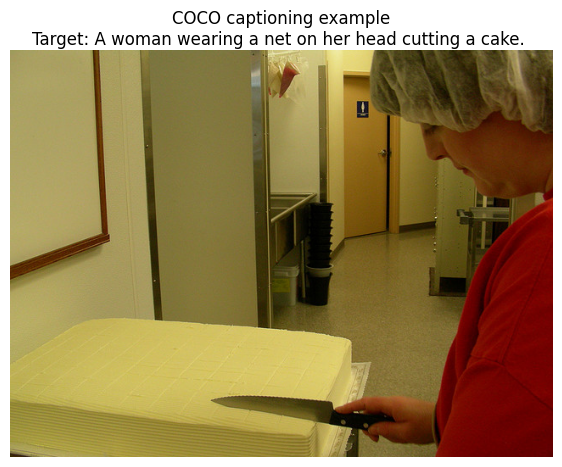


========== π0.5 PRETRAINING INTERPRETATION ==========

INPUT
-----
image:
    (480, 640, 3)

task prompt:
    'Caption the image:'

robot state:
    NONE

TARGET
------
ordinary language:
    'A woman wearing a net on her head cutting a cake. '

NEXT STAGES
-----------
PaliGemma text tokenization
        ↓
ordinary vocabulary token IDs
        ↓
autoregressive next-token targets
        ↓
next-token cross entropy



In [9]:
# Cell 5 — inspect COCO as a π0.5 heterogeneous pretraining source

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Select one deterministic COCO example
# ============================================================

example = coco[0]

print("========== COCO CAPTIONING DATA ==========")

print("columns:")
print(coco.column_names)

print("\nnumber of downloaded rows:")
print(len(coco))


# ============================================================
# Inspect raw example
# ============================================================

image = example["image"]
caption = example["caption"]
coco_id = example["cocoid"]

image_np = np.asarray(image)

print("\n========== RAW COCO EXAMPLE ==========")

print("COCO image id:")
print(coco_id)

print("\nimage:")
print(" shape:", image_np.shape)
print(" dtype:", image_np.dtype)

print("\ncaption:")
print(repr(caption))


# ============================================================
# Show that multiple captions can correspond to one image
# ============================================================

same_image_indices = [
    i
    for i, cid in enumerate(coco["cocoid"])
    if cid == coco_id
]

same_image_captions = [
    coco[i]["caption"]
    for i in same_image_indices[:5]
]

print("\n========== CAPTIONS FOR SAME IMAGE ==========")

print("number found in our subset:", len(same_image_indices))

for i, text in enumerate(same_image_captions):
    print(f"{i + 1}. {text}")


# ============================================================
# Define our captioning task representation
#
# IMPORTANT:
# π0.5 says captioning is part of web-data pretraining,
# but the paper does not specify the exact textual prompt.
#
# "Caption the image:" is therefore OUR reproduction prompt.
# ============================================================

task_prompt = "Caption the image:"

training_input = {
    "image": image,
    "prompt": task_prompt,
}

training_target = caption


print("\n========== MODEL INPUT / TARGET ==========")

print("INPUT")
print("-----")
print("image:")
print(" ", image_np.shape)

print("\nprompt:")
print(" ", repr(task_prompt))

print("\nTARGET")
print("------")
print("caption text:")
print(" ", repr(training_target))


# ============================================================
# Visualize
# ============================================================

plt.figure(figsize=(7, 6))
plt.imshow(image)
plt.title(
    f"COCO captioning example\nTarget: {caption}",
    wrap=True,
)
plt.axis("off")
plt.show()


# ============================================================
# π0.5 heterogeneous-pretraining interpretation
# ============================================================

print("\n========== π0.5 PRETRAINING INTERPRETATION ==========")

print(f"""
INPUT
-----
image:
    {image_np.shape}

task prompt:
    {task_prompt!r}

robot state:
    NONE

TARGET
------
ordinary language:
    {caption!r}

NEXT STAGES
-----------
PaliGemma text tokenization
        ↓
ordinary vocabulary token IDs
        ↓
autoregressive next-token targets
        ↓
next-token cross entropy
""")

========== VQAv2 DATA ==========
columns:
['multiple_choice_answer', 'question', 'image']

number of downloaded rows:
2500

========== RAW VQAv2 EXAMPLE ==========
image:
 shape: (424, 640, 3)
 dtype: uint8

question:
'Where are the kids riding?'

answer:
'carnival ride'

========== MODEL INPUT / TARGET ==========
INPUT
-----
image:
  (424, 640, 3)

prompt:
  'Question: Where are the kids riding?\nAnswer:'

TARGET
------
answer text:
  'carnival ride'


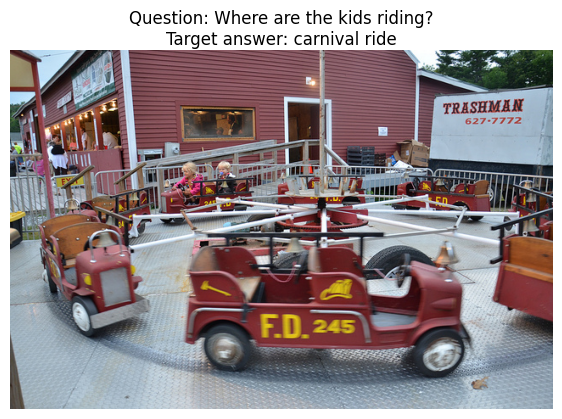


========== π0.5 PRETRAINING INTERPRETATION ==========

INPUT
-----
image:
    (424, 640, 3)

question:
    'Where are the kids riding?'

task prompt serialization:
    'Question: Where are the kids riding?\nAnswer:'

robot state:
    NONE

TARGET
------
ordinary language answer:
    'carnival ride'

NEXT STAGES
-----------
PaliGemma text tokenization
        ↓
ordinary vocabulary token IDs
        ↓
autoregressive next-token targets
        ↓
next-token cross entropy



In [10]:
# Cell 6 — inspect VQAv2 as a π0.5 heterogeneous pretraining source

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Select one deterministic VQAv2 example
# ============================================================

example = vqa[0]

image = example["image"]
question = example["question"]
answer = example["multiple_choice_answer"]

image_np = np.asarray(image)


print("========== VQAv2 DATA ==========")

print("columns:")
print(vqa.column_names)

print("\nnumber of downloaded rows:")
print(len(vqa))


# ============================================================
# Inspect raw example
# ============================================================

print("\n========== RAW VQAv2 EXAMPLE ==========")

print("image:")
print(" shape:", image_np.shape)
print(" dtype:", image_np.dtype)

print("\nquestion:")
print(repr(question))

print("\nanswer:")
print(repr(answer))


# ============================================================
# Define our VQA serialization
#
# π0.5 tells us that VQA examples are part of pretraining,
# but does not publish the exact literal prompt formatting.
#
# The wording below is OUR reproduction convention.
# ============================================================

task_prompt = f"Question: {question}\nAnswer:"


print("\n========== MODEL INPUT / TARGET ==========")

print("INPUT")
print("-----")

print("image:")
print(" ", image_np.shape)

print("\nprompt:")
print(" ", repr(task_prompt))


print("\nTARGET")
print("------")

print("answer text:")
print(" ", repr(answer))


# ============================================================
# Visualize
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(image)

plt.title(
    f"Question: {question}\nTarget answer: {answer}",
    wrap=True,
)

plt.axis("off")
plt.show()


# ============================================================
# π0.5 heterogeneous-pretraining interpretation
# ============================================================

print("\n========== π0.5 PRETRAINING INTERPRETATION ==========")

print(f"""
INPUT
-----
image:
    {image_np.shape}

question:
    {question!r}

task prompt serialization:
    {task_prompt!r}

robot state:
    NONE

TARGET
------
ordinary language answer:
    {answer!r}

NEXT STAGES
-----------
PaliGemma text tokenization
        ↓
ordinary vocabulary token IDs
        ↓
autoregressive next-token targets
        ↓
next-token cross entropy
""")

In [11]:
# Cell 7 — unified heterogeneous example representation

from dataclasses import dataclass
from typing import Optional

import numpy as np


# ============================================================
# Common dimensions for our miniature π0.5 reproduction
# ============================================================

NUM_IMAGE_SLOTS = 3
COMMON_STATE_DIM = 14
COMMON_ACTION_DIM = 14
ACTION_HORIZON = 50


# ============================================================
# Unified pre-tokenization example
# ============================================================

@dataclass
class UnifiedExample:
    # Debugging / sampling metadata.
    # These are NOT hidden task embeddings given to the model.
    source: str
    task_type: str

    # Fixed three-image model interface.
    images: tuple[np.ndarray, np.ndarray, np.ndarray]
    image_mask: np.ndarray

    # Common robot-state interface.
    # Web examples use zeros with state_mask=False.
    state: np.ndarray
    state_mask: np.ndarray

    # Natural-language context shown to the model.
    prompt: str

    # Exactly ONE of these target types should be present.
    actions: Optional[np.ndarray] = None
    text_target: Optional[str] = None


# ============================================================
# Validation
# ============================================================

def validate_unified_example(example: UnifiedExample):
    assert len(example.images) == NUM_IMAGE_SLOTS

    assert example.image_mask.shape == (NUM_IMAGE_SLOTS,)
    assert example.image_mask.dtype == bool

    assert example.state.shape == (COMMON_STATE_DIM,)
    assert example.state_mask.shape == (COMMON_STATE_DIM,)
    assert example.state_mask.dtype == bool

    has_actions = example.actions is not None
    has_text = example.text_target is not None

    # A training example must supervise exactly one output type.
    assert has_actions ^ has_text, (
        "Example must contain exactly one of: "
        "actions or text_target."
    )

    if has_actions:
        assert example.actions.shape == (
            ACTION_HORIZON,
            COMMON_ACTION_DIM,
        )

    if has_text:
        assert isinstance(example.text_target, str)
        assert len(example.text_target) > 0


# ============================================================
# Helper for absent image slots
# ============================================================

def blank_image_like(image):
    return np.zeros_like(image)


# ============================================================
# Show the intended four source contracts
# ============================================================

print("========== UNIFIED HETEROGENEOUS SCHEMA ==========")

print(f"""
COMMON MODEL INTERFACE

images:
    {NUM_IMAGE_SLOTS} fixed image slots

image_mask:
    ({NUM_IMAGE_SLOTS},)

state:
    ({COMMON_STATE_DIM},)

state_mask:
    ({COMMON_STATE_DIM},)

prompt:
    string

target:
    EITHER

    robot actions:
        ({ACTION_HORIZON}, {COMMON_ACTION_DIM})

    OR

    ordinary text:
        string


SOURCE MAPPING
--------------

ALOHA
    images      → 3 robot views
    state       → 14-D
    state mask  → 14 valid
    prompt      → robot instruction
    target      → (50,14) actions

DROID
    images      → exterior + padded slot + wrist
    state       → 8-D padded to 14-D
    state mask  → first 8 valid
    prompt      → robot instruction
    target      → (50,8) padded to (50,14)

COCO
    images      → image + padded slots
    state       → zeros
    state mask  → all false
    prompt      → captioning instruction
    target      → caption text

VQAv2
    images      → image + padded slots
    state       → zeros
    state mask  → all false
    prompt      → question / answer context
    target      → answer text
""")


# ============================================================
# Important distinction
# ============================================================

print("========== MODEL-VISIBLE VS TRAINING-ONLY ==========")

print("""
MODEL-VISIBLE
-------------
images
image masks
state
state mask
prompt

TRAINING / DEBUGGING ONLY
-------------------------
source
task_type

SUPERVISION
-----------
actions OR text_target

The model is not given a learned label such as:

    task_type = "VQA"

to tell it what to do.

The natural-language context and available modalities
define the task.
""")

========== UNIFIED HETEROGENEOUS SCHEMA ==========

COMMON MODEL INTERFACE

images:
    3 fixed image slots

image_mask:
    (3,)

state:
    (14,)

state_mask:
    (14,)

prompt:
    string

target:
    EITHER

    robot actions:
        (50, 14)

    OR

    ordinary text:
        string


SOURCE MAPPING
--------------

ALOHA
    images      → 3 robot views
    state       → 14-D
    state mask  → 14 valid
    prompt      → robot instruction
    target      → (50,14) actions

DROID
    images      → exterior + padded slot + wrist
    state       → 8-D padded to 14-D
    state mask  → first 8 valid
    prompt      → robot instruction
    target      → (50,8) padded to (50,14)

COCO
    images      → image + padded slots
    state       → zeros
    state mask  → all false
    prompt      → captioning instruction
    target      → caption text

VQAv2
    images      → image + padded slots
    state       → zeros
    state mask  → all false
    prompt      → question / answer context
   

In [12]:
# Cell 8 — build one UnifiedExample from each dataset

import numpy as np


# ============================================================
# Generic helpers
# ============================================================

def pad_vector(x, target_dim):
    x = np.asarray(x, dtype=np.float32)

    assert x.ndim == 1
    assert x.shape[0] <= target_dim

    out = np.zeros(target_dim, dtype=np.float32)
    out[:x.shape[0]] = x

    mask = np.zeros(target_dim, dtype=bool)
    mask[:x.shape[0]] = True

    return out, mask


def pad_actions(actions, target_dim):
    actions = np.asarray(actions, dtype=np.float32)

    assert actions.ndim == 2
    assert actions.shape[1] <= target_dim

    out = np.zeros(
        (actions.shape[0], target_dim),
        dtype=np.float32,
    )

    out[:, :actions.shape[1]] = actions

    return out


def make_three_image_slots(
    image0,
    image1=None,
    image2=None,
):
    """
    Standardize every example to three image slots.

    Missing images are represented with zeros and mask=False.
    """

    image0 = np.asarray(image0)

    if image1 is None:
        image1 = np.zeros_like(image0)
        mask1 = False
    else:
        image1 = np.asarray(image1)
        mask1 = True

    if image2 is None:
        image2 = np.zeros_like(image0)
        mask2 = False
    else:
        image2 = np.asarray(image2)
        mask2 = True

    return (
        (image0, image1, image2),
        np.asarray(
            [True, mask1, mask2],
            dtype=bool,
        ),
    )


# ============================================================
# ALOHA adapter
# ============================================================

def make_aloha_unified_example():
    # Use the episode/sample already loaded in Cell 3.
    sample = aloha[0]

    state = as_numpy(
        sample["observation.state"]
    )

    actions = as_numpy(
        sample["action"]
    )

    prompt = (
        sample["task"]
        if "task" in sample
        else
        "Pick up the screwdriver with the right arm, "
        "hand it over to the left arm then place it into the cup."
    )

    # --------------------------------------------------------
    # Repack through OpenPI's actual ALOHA adapter
    # --------------------------------------------------------

    aloha_input = {
        "images": {
            "cam_high":
                as_numpy(
                    sample["observation.images.cam_high"]
                ),

            "cam_low":
                as_numpy(
                    sample["observation.images.cam_low"]
                ),

            "cam_left_wrist":
                as_numpy(
                    sample["observation.images.cam_left_wrist"]
                ),

            "cam_right_wrist":
                as_numpy(
                    sample["observation.images.cam_right_wrist"]
                ),
        },

        "state": state,
        "actions": actions,
        "prompt": prompt,
    }

    adapted = aloha_policy.AlohaInputs(
        adapt_to_pi=True
    )(aloha_input)

    # --------------------------------------------------------
    # ALOHA joint actions:
    #
    # 6 delta joints
    # 1 absolute gripper
    # 6 delta joints
    # 1 absolute gripper
    # --------------------------------------------------------

    delta_mask = transforms.make_bool_mask(
        6, -1,
        6, -1,
    )

    transformed = transforms.DeltaActions(
        delta_mask
    )(
        {
            "state": adapted["state"],
            "actions": adapted["actions"],
        }
    )

    # ALOHA already defines our 14-D ceiling.
    state_14 = np.asarray(
        adapted["state"],
        dtype=np.float32,
    )

    actions_14 = np.asarray(
        transformed["actions"],
        dtype=np.float32,
    )

    state_mask = np.ones(
        COMMON_STATE_DIM,
        dtype=bool,
    )

    images = (
        adapted["image"]["base_0_rgb"],
        adapted["image"]["left_wrist_0_rgb"],
        adapted["image"]["right_wrist_0_rgb"],
    )

    image_mask = np.asarray(
        [True, True, True],
        dtype=bool,
    )

    example = UnifiedExample(
        source="aloha",
        task_type="robot_action",

        images=images,
        image_mask=image_mask,

        state=state_14,
        state_mask=state_mask,

        prompt=prompt,

        actions=actions_14,
        text_target=None,
    )

    validate_unified_example(example)

    return example


# ============================================================
# DROID adapter
# ============================================================

def make_droid_unified_example():
    # Reuse the real 50-step trajectory loaded in Cell 4.
    chunk = trajectory[:ACTION_HORIZON]
    step0 = chunk[0]

    camera_types = step0["observation"]["camera_type"]

    wrist_ids = [
        camera_id
        for camera_id, camera_type
        in camera_types.items()
        if camera_type == 0
    ]

    exterior_ids = [
        camera_id
        for camera_id, camera_type
        in camera_types.items()
        if camera_type != 0
    ]

    # --------------------------------------------------------
    # Images
    #
    # Follow the public OpenPI FAST DROID convention:
    #
    # slot 0 = exterior camera 1
    # slot 1 = absent/padded
    # slot 2 = wrist camera
    #
    # We preserve exterior camera 2 in the raw dataset,
    # but do not expose it to the model in this reproduction.
    # --------------------------------------------------------

    exterior = droid_converter.resize_image(
        step0["observation"]["image"][
            exterior_ids[0]
        ][..., ::-1],
        (320, 180),
    )

    wrist = droid_converter.resize_image(
        step0["observation"]["image"][
            wrist_ids[0]
        ][..., ::-1],
        (320, 180),
    )

    blank = np.zeros_like(exterior)

    images = (
        exterior,
        blank,
        wrist,
    )

    image_mask = np.asarray(
        [True, False, True],
        dtype=bool,
    )

    # --------------------------------------------------------
    # 8-D DROID state
    # --------------------------------------------------------

    joint_position = np.asarray(
        step0["observation"]["robot_state"][
            "joint_positions"
        ],
        dtype=np.float32,
    )

    gripper_position = np.asarray(
        [
            step0["observation"]["robot_state"][
                "gripper_position"
            ]
        ],
        dtype=np.float32,
    ).reshape(-1)

    state_8 = np.concatenate(
        [
            joint_position,
            gripper_position,
        ]
    )

    state_14, state_mask = pad_vector(
        state_8,
        COMMON_STATE_DIM,
    )

    # --------------------------------------------------------
    # 50 × 8 DROID actions
    # --------------------------------------------------------

    actions_8 = np.stack(
        [
            np.concatenate(
                [
                    np.asarray(
                        step["action"][
                            "joint_velocity"
                        ],
                        dtype=np.float32,
                    ),

                    np.asarray(
                        [
                            step["action"][
                                "gripper_position"
                            ]
                        ],
                        dtype=np.float32,
                    ).reshape(-1),
                ]
            )

            for step in chunk
        ]
    )

    actions_14 = pad_actions(
        actions_8,
        COMMON_ACTION_DIM,
    )

    example = UnifiedExample(
        source="droid",
        task_type="robot_action",

        images=images,
        image_mask=image_mask,

        state=state_14,
        state_mask=state_mask,

        prompt=prompt,

        actions=actions_14,
        text_target=None,
    )

    validate_unified_example(example)

    return example


# ============================================================
# COCO adapter
# ============================================================

def make_coco_unified_example():
    raw = coco[0]

    image = np.asarray(
        raw["image"].convert("RGB")
    )

    images, image_mask = make_three_image_slots(
        image
    )

    state = np.zeros(
        COMMON_STATE_DIM,
        dtype=np.float32,
    )

    state_mask = np.zeros(
        COMMON_STATE_DIM,
        dtype=bool,
    )

    example = UnifiedExample(
        source="coco",
        task_type="caption",

        images=images,
        image_mask=image_mask,

        state=state,
        state_mask=state_mask,

        # Our reproduction serialization.
        prompt="Caption the image:",

        actions=None,
        text_target=raw["caption"].strip(),
    )

    validate_unified_example(example)

    return example


# ============================================================
# VQAv2 adapter
# ============================================================

def make_vqa_unified_example():
    raw = vqa[0]

    image = np.asarray(
        raw["image"].convert("RGB")
    )

    images, image_mask = make_three_image_slots(
        image
    )

    state = np.zeros(
        COMMON_STATE_DIM,
        dtype=np.float32,
    )

    state_mask = np.zeros(
        COMMON_STATE_DIM,
        dtype=bool,
    )

    question = raw["question"]
    answer = raw["multiple_choice_answer"]

    example = UnifiedExample(
        source="vqav2",
        task_type="vqa",

        images=images,
        image_mask=image_mask,

        state=state,
        state_mask=state_mask,

        prompt=(
            f"Question: {question}\n"
            "Answer:"
        ),

        actions=None,
        text_target=answer.strip(),
    )

    validate_unified_example(example)

    return example


# ============================================================
# Build one example from each source
# ============================================================

aloha_example = make_aloha_unified_example()
droid_example = make_droid_unified_example()
coco_example = make_coco_unified_example()
vqa_example = make_vqa_unified_example()

examples = [
    aloha_example,
    droid_example,
    coco_example,
    vqa_example,
]


# ============================================================
# Compare all four side-by-side
# ============================================================

print(
    "========== UNIFIED EXAMPLES =========="
)

for ex in examples:

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"{ex.source.upper()} / "
        f"{ex.task_type}"
    )

    print(
        f"{'=' * 60}"
    )

    print(
        "image shapes:"
    )

    for i, image in enumerate(
        ex.images
    ):
        print(
            f"  slot {i}: "
            f"{image.shape}"
        )

    print(
        "image mask: ",
        ex.image_mask.astype(int),
    )

    print(
        "state shape:",
        ex.state.shape,
    )

    print(
        "state mask: ",
        ex.state_mask.astype(int),
    )

    print(
        "prompt:",
        repr(ex.prompt),
    )

    if ex.actions is not None:

        print(
            "target type: ACTION"
        )

        print(
            "target shape:",
            ex.actions.shape,
        )

        print(
            "nonzero action dimensions:",
            np.where(
                np.any(
                    ex.actions != 0,
                    axis=0,
                )
            )[0].tolist(),
        )

    else:

        print(
            "target type: TEXT"
        )

        print(
            "target:",
            repr(ex.text_target),
        )


print(
    "\n========== RESULT =========="
)

print("""
All four datasets now satisfy the same
pre-tokenization training interface.

The source-specific differences have been pushed
into the adapters.

Next:

robot examples
    → source-specific q01/q99 normalization
    → FAST

text examples
    → ordinary text tokenizer

then both paths
    → token IDs
    → target mask
    → autoregressive next-token CE
""")

========== UNIFIED EXAMPLES ==========

ALOHA / robot_action
image shapes:
  slot 0: (480, 640, 3)
  slot 1: (480, 640, 3)
  slot 2: (480, 640, 3)
image mask:  [1 1 1]
state shape: (14,)
state mask:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1]
prompt: 'Pick up the screwdriver with the right arm, hand it over to the left arm then place it into the cup.'
target type: ACTION
target shape: (50, 14)
nonzero action dimensions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

DROID / robot_action
image shapes:
  slot 0: (180, 320, 3)
  slot 1: (180, 320, 3)
  slot 2: (180, 320, 3)
image mask:  [1 0 1]
state shape: (14,)
state mask:  [1 1 1 1 1 1 1 1 0 0 0 0 0 0]
prompt: 'Remove the glass lid from the silver pot'
target type: ACTION
target shape: (50, 14)
nonzero action dimensions: [0, 1, 2, 3, 4, 5, 6]

COCO / caption
image shapes:
  slot 0: (480, 640, 3)
  slot 1: (480, 640, 3)
  slot 2: (480, 640, 3)
image mask:  [1 0 0]
state shape: (14,)
state mask:  [0 0 0 0 0 0 0 0 0 0 0 0 0 0]
prompt: 'Caption the im

In [13]:
# Cell 9 — source-specific normalization + unified token sequences

from pathlib import Path

import numpy as np

from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
from openpi.models import tokenizer as openpi_tokenizer


# ============================================================
# Training splits used by THIS miniature reproduction
# ============================================================

ALOHA_TRAIN_EPISODES = list(range(8))
ALOHA_VAL_EPISODES = [8, 9]

DROID_ALL_PATHS = sorted(
    DROID_RAW_DIR.rglob("trajectory.h5")
)

DROID_TRAIN_PATHS = DROID_ALL_PATHS[:24]
DROID_VAL_PATHS = DROID_ALL_PATHS[24:30]

NORM_STATS_PATH = (
    DATA_ROOT / "robot_quantile_stats.npz"
)


print("========== TRAINING SPLITS ==========")

print(
    "ALOHA:",
    len(ALOHA_TRAIN_EPISODES),
    "train /",
    len(ALOHA_VAL_EPISODES),
    "held out",
)

print(
    "DROID:",
    len(DROID_TRAIN_PATHS),
    "train /",
    len(DROID_VAL_PATHS),
    "held out",
)


# ============================================================
# Helpers
# ============================================================

def future_action_chunks(actions, horizon=50):
    """
    Convert a trajectory [T,D] into future chunks [T,H,D].

    At the end of an episode, repeat the final action so every
    training example still has a fixed 50-step target.
    """

    T = actions.shape[0]

    indices = (
        np.arange(T)[:, None]
        + np.arange(horizon)[None, :]
    )

    indices = np.clip(
        indices,
        0,
        T - 1,
    )

    return actions[indices]


def quantile_stats(x):
    x = np.asarray(x, dtype=np.float32)

    return {
        "q01": np.quantile(
            x,
            0.01,
            axis=0,
        ).astype(np.float32),

        "q99": np.quantile(
            x,
            0.99,
            axis=0,
        ).astype(np.float32),
    }


def quantile_normalize(x, q01, q99):
    """
    Same q01/q99 mapping used by OpenPI Normalize:

        q01 -> -1
        q99 -> +1
    """

    x = np.asarray(x, dtype=np.float32)

    return (
        (x - q01)
        / (q99 - q01 + 1e-6)
        * 2.0
        - 1.0
    )


# ============================================================
# Compute statistics only if not already cached
# ============================================================

if NORM_STATS_PATH.exists():

    print("\nLoading cached robot normalization statistics...")

    cached = np.load(NORM_STATS_PATH)

    aloha_state_q01 = cached["aloha_state_q01"]
    aloha_state_q99 = cached["aloha_state_q99"]

    aloha_action_q01 = cached["aloha_action_q01"]
    aloha_action_q99 = cached["aloha_action_q99"]

    droid_state_q01 = cached["droid_state_q01"]
    droid_state_q99 = cached["droid_state_q99"]

    droid_action_q01 = cached["droid_action_q01"]
    droid_action_q99 = cached["droid_action_q99"]


else:

    # ========================================================
    # ALOHA statistics
    # ========================================================

    print("\nComputing ALOHA q01/q99 from episodes 0-7...")

    aloha_states_for_stats = []
    aloha_actions_for_stats = []

    aloha_delta_mask = np.asarray(
        transforms.make_bool_mask(
            6, -1,
            6, -1,
        ),
        dtype=bool,
    )

    for episode_index in ALOHA_TRAIN_EPISODES:

        ds = LeRobotDataset(
            repo_id=ALOHA_REPO,
            root=ALOHA_DIR,
            episodes=[episode_index],
        )

        # Access the underlying HF columns directly so we do
        # not waste time decoding thousands of video frames.
        raw_states = np.stack(
            [
                as_numpy(x)
                for x in ds.hf_dataset[
                    "observation.state"
                ]
            ]
        ).astype(np.float32)

        raw_actions = np.stack(
            [
                as_numpy(x)
                for x in ds.hf_dataset[
                    "action"
                ]
            ]
        ).astype(np.float32)


        # ----------------------------------------------------
        # Apply the same ALOHA -> PI convention as AlohaInputs.
        # ----------------------------------------------------

        states_pi = np.stack(
            [
                aloha_policy._decode_state(
                    state.copy(),
                    adapt_to_pi=True,
                )
                for state in raw_states
            ]
        )

        actions_pi = (
            aloha_policy._encode_actions_inv(
                raw_actions.copy(),
                adapt_to_pi=True,
            )
        )


        # ----------------------------------------------------
        # Construct 50-step chunks.
        # ----------------------------------------------------

        chunks = future_action_chunks(
            actions_pi,
            ACTION_HORIZON,
        )


        # ----------------------------------------------------
        # Absolute joints -> delta joints.
        #
        # Each future action is expressed relative to the
        # CURRENT state for that training example.
        # ----------------------------------------------------

        chunks[
            ...,
            aloha_delta_mask
        ] -= states_pi[
            :,
            None,
            aloha_delta_mask
        ]


        aloha_states_for_stats.append(
            states_pi
        )

        aloha_actions_for_stats.append(
            chunks.reshape(
                -1,
                COMMON_ACTION_DIM,
            )
        )


    aloha_states_for_stats = np.concatenate(
        aloha_states_for_stats,
        axis=0,
    )

    aloha_actions_for_stats = np.concatenate(
        aloha_actions_for_stats,
        axis=0,
    )


    aloha_state_stats = quantile_stats(
        aloha_states_for_stats
    )

    aloha_action_stats = quantile_stats(
        aloha_actions_for_stats
    )


    aloha_state_q01 = aloha_state_stats["q01"]
    aloha_state_q99 = aloha_state_stats["q99"]

    aloha_action_q01 = aloha_action_stats["q01"]
    aloha_action_q99 = aloha_action_stats["q99"]


    # ========================================================
    # DROID statistics
    # ========================================================

    print("Computing DROID q01/q99 from 24 trajectories...")

    droid_states_for_stats = []
    droid_actions_for_stats = []

    for episode_path in DROID_TRAIN_PATHS:

        # Read only HDF5 low-dimensional values.
        # No MP4 decoding is needed for normalization stats.
        reader = droid_converter.TrajectoryReader(
            str(episode_path),
            read_images=False,
        )

        episode_states = []
        episode_actions = []

        for _ in range(reader.length()):

            step = reader.read_timestep()

            joint_position = np.asarray(
                step["observation"][
                    "robot_state"
                ]["joint_positions"],
                dtype=np.float32,
            )

            gripper_position = np.asarray(
                [
                    step["observation"][
                        "robot_state"
                    ]["gripper_position"]
                ],
                dtype=np.float32,
            ).reshape(-1)

            state_8 = np.concatenate(
                [
                    joint_position,
                    gripper_position,
                ]
            )


            joint_velocity = np.asarray(
                step["action"][
                    "joint_velocity"
                ],
                dtype=np.float32,
            )

            gripper_action = np.asarray(
                [
                    step["action"][
                        "gripper_position"
                    ]
                ],
                dtype=np.float32,
            ).reshape(-1)

            action_8 = np.concatenate(
                [
                    joint_velocity,
                    gripper_action,
                ]
            )


            episode_states.append(
                state_8
            )

            episode_actions.append(
                action_8
            )


        reader.close()

        episode_states = np.stack(
            episode_states
        )

        episode_actions = np.stack(
            episode_actions
        )


        # Build the same 50-step targets that the model sees.
        episode_chunks = future_action_chunks(
            episode_actions,
            ACTION_HORIZON,
        )


        droid_states_for_stats.append(
            episode_states
        )

        droid_actions_for_stats.append(
            episode_chunks.reshape(
                -1,
                8,
            )
        )


    droid_states_for_stats = np.concatenate(
        droid_states_for_stats,
        axis=0,
    )

    droid_actions_for_stats = np.concatenate(
        droid_actions_for_stats,
        axis=0,
    )


    droid_state_stats = quantile_stats(
        droid_states_for_stats
    )

    droid_action_stats = quantile_stats(
        droid_actions_for_stats
    )


    droid_state_q01 = droid_state_stats["q01"]
    droid_state_q99 = droid_state_stats["q99"]

    droid_action_q01 = droid_action_stats["q01"]
    droid_action_q99 = droid_action_stats["q99"]


    # ========================================================
    # Save so the notebook never has to recompute this
    # ========================================================

    np.savez(
        NORM_STATS_PATH,

        aloha_state_q01=aloha_state_q01,
        aloha_state_q99=aloha_state_q99,

        aloha_action_q01=aloha_action_q01,
        aloha_action_q99=aloha_action_q99,

        droid_state_q01=droid_state_q01,
        droid_state_q99=droid_state_q99,

        droid_action_q01=droid_action_q01,
        droid_action_q99=droid_action_q99,
    )

    print(
        "Saved:",
        NORM_STATS_PATH,
    )


# ============================================================
# Show that stats remain embodiment-specific
# ============================================================

print("\n========== NORMALIZATION STATS ==========")

print(
    "ALOHA state stats:",
    aloha_state_q01.shape,
)

print(
    "ALOHA action stats:",
    aloha_action_q01.shape,
)

print(
    "DROID state stats:",
    droid_state_q01.shape,
)

print(
    "DROID action stats:",
    droid_action_q01.shape,
)


# ============================================================
# Normalize our two example robot records
#
# IMPORTANT:
# Normalize the native dimensionality FIRST.
# Pad DROID only AFTER normalization.
# ============================================================

aloha_state_norm = quantile_normalize(
    aloha_example.state,
    aloha_state_q01,
    aloha_state_q99,
)

aloha_actions_norm = quantile_normalize(
    aloha_example.actions,
    aloha_action_q01,
    aloha_action_q99,
)


# DROID's real state/action space is only 8-D.
droid_state_8 = droid_example.state[:8]
droid_actions_8 = droid_example.actions[:, :8]

droid_state_8_norm = quantile_normalize(
    droid_state_8,
    droid_state_q01,
    droid_state_q99,
)

droid_actions_8_norm = quantile_normalize(
    droid_actions_8,
    droid_action_q01,
    droid_action_q99,
)


# Now zero-pad normalized DROID data to the common 14-D ceiling.
droid_state_norm = np.zeros(
    COMMON_STATE_DIM,
    dtype=np.float32,
)

droid_state_norm[:8] = droid_state_8_norm


droid_actions_norm = np.zeros(
    (
        ACTION_HORIZON,
        COMMON_ACTION_DIM,
    ),
    dtype=np.float32,
)

droid_actions_norm[:, :8] = droid_actions_8_norm


print("\n========== NORMALIZED EXAMPLES ==========")

print(
    "ALOHA state range:",
    float(aloha_state_norm.min()),
    "to",
    float(aloha_state_norm.max()),
)

print(
    "ALOHA actions range:",
    float(aloha_actions_norm.min()),
    "to",
    float(aloha_actions_norm.max()),
)

print(
    "DROID state range:",
    float(droid_state_8_norm.min()),
    "to",
    float(droid_state_8_norm.max()),
)

print(
    "DROID actions range:",
    float(droid_actions_8_norm.min()),
    "to",
    float(droid_actions_8_norm.max()),
)


# ============================================================
# Shared PaliGemma / FAST vocabulary
# ============================================================

MAX_TOKEN_LEN = 256

fast_tokenizer = openpi_tokenizer.FASTTokenizer(
    max_len=MAX_TOKEN_LEN
)

# FASTTokenizer itself contains the exact PaliGemma
# SentencePiece vocabulary into which FAST codes are mapped.
paligemma_sp = (
    fast_tokenizer._paligemma_tokenizer
)

print("\nPaliGemma vocabulary size:")
print(
    paligemma_sp.vocab_size()
)


# ============================================================
# Robot task tokenization
#
# This is OpenPI's real FAST serialization.
# ============================================================

def tokenize_robot_task(
    example,
    normalized_state,
    normalized_actions,
):

    (
        tokens,
        token_mask,
        ar_mask,
        loss_mask,
    ) = fast_tokenizer.tokenize(
        example.prompt,
        normalized_state,
        normalized_actions,
    )

    return {
        "tokens": tokens,
        "token_mask": token_mask,
        "ar_mask": ar_mask.astype(bool),
        "loss_mask": loss_mask.astype(bool),
    }


# ============================================================
# Text-task tokenization
#
# Public OpenPI does not expose π0.5's original web-data
# adapter, so this small wrapper implements the same conceptual
# prefix -> autoregressive target structure using THE SAME
# PaliGemma SentencePiece vocabulary.
# ============================================================

def tokenize_text_task(
    example,
    max_len=MAX_TOKEN_LEN,
):

    # Prompt/context is visible but does not receive CE loss.
    cleaned_prompt = (
        example.prompt
        .strip()
        .replace("_", " ")
    )

    prefix_tokens = (
        paligemma_sp.encode(
            cleaned_prompt,
            add_bos=True,
        )
        +
        paligemma_sp.encode("\n")
    )


    # Caption / answer is the autoregressive target.
    target_tokens = paligemma_sp.encode(
        example.text_target,
        add_eos=True,
    )


    tokens = (
        prefix_tokens
        +
        target_tokens
    )

    token_mask = (
        [True] * len(tokens)
    )

    ar_mask = (
        [False] * len(prefix_tokens)
        +
        [True] * len(target_tokens)
    )

    loss_mask = (
        [False] * len(prefix_tokens)
        +
        [True] * len(target_tokens)
    )


    # Pad / truncate to the same sequence length.
    if len(tokens) < max_len:

        n_pad = (
            max_len - len(tokens)
        )

        tokens += [0] * n_pad
        token_mask += [False] * n_pad
        ar_mask += [False] * n_pad
        loss_mask += [False] * n_pad

    else:

        tokens = tokens[:max_len]
        token_mask = token_mask[:max_len]
        ar_mask = ar_mask[:max_len]
        loss_mask = loss_mask[:max_len]


    return {
        "tokens": np.asarray(
            tokens,
            dtype=np.int32,
        ),

        "token_mask": np.asarray(
            token_mask,
            dtype=bool,
        ),

        "ar_mask": np.asarray(
            ar_mask,
            dtype=bool,
        ),

        "loss_mask": np.asarray(
            loss_mask,
            dtype=bool,
        ),
    }


# ============================================================
# Tokenize all four tasks
# ============================================================

tokenized_examples = {

    "aloha": tokenize_robot_task(
        aloha_example,
        aloha_state_norm,
        aloha_actions_norm,
    ),

    "droid": tokenize_robot_task(
        droid_example,
        droid_state_norm,
        droid_actions_norm,
    ),

    "coco": tokenize_text_task(
        coco_example,
    ),

    "vqav2": tokenize_text_task(
        vqa_example,
    ),
}


# ============================================================
# Compare the resulting autoregressive sequences
# ============================================================

print(
    "\n========== AUTOREGRESSIVE TOKEN SEQUENCES =========="
)

for name, packed in tokenized_examples.items():

    active = packed["token_mask"]
    supervised = packed["loss_mask"]

    active_tokens = packed["tokens"][
        active
    ]

    target_tokens = packed["tokens"][
        supervised
    ]

    print(
        f"\n{name.upper()}"
    )

    print(
        "active tokens:     ",
        int(active.sum()),
    )

    print(
        "supervised tokens: ",
        int(supervised.sum()),
    )

    print(
        "token array shape: ",
        packed["tokens"].shape,
    )

    print(
        "target token IDs:  ",
        target_tokens[:20],
    )


    if name in (
        "coco",
        "vqav2",
    ):

        print(
            "decoded target:   ",
            repr(
                paligemma_sp.decode(
                    target_tokens.tolist()
                )
            ),
        )


print(
    "\n========== THE IMPORTANT RESULT =========="
)

print("""
ALOHA
    images + normalized state + instruction
        → PaliGemma prefix tokens
        → FAST action tokens

DROID
    images + independently-normalized state + instruction
        → PaliGemma prefix tokens
        → FAST action tokens

COCO
    image + caption prompt
        → PaliGemma prefix tokens
        → ordinary caption tokens

VQAv2
    image + question
        → PaliGemma prefix tokens
        → ordinary answer tokens

ALL FOUR:
    token array     = (256,)
    AR mask         = (256,)
    loss mask       = (256,)
    vocabulary      = SAME PaliGemma vocabulary
    objective       = SAME next-token cross entropy
""")

========== TRAINING SPLITS ==========
ALOHA: 8 train / 2 held out
DROID: 24 train / 6 held out

Computing ALOHA q01/q99 from episodes 0-7...


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Computing DROID q01/q99 from 24 trajectories...
Saved: /home/osx/openpi/data/pi05_heterogeneous/robot_quantile_stats.npz

========== NORMALIZATION STATS ==========
ALOHA state stats: (14,)
ALOHA action stats: (14,)
DROID state stats: (8,)
DROID action stats: (8,)

========== NORMALIZED EXAMPLES ==========
ALOHA state range: -1.0797266960144043 to 1.0210943222045898
ALOHA actions range: -1.1363039016723633 to 0.9614013433456421
DROID state range: -1.0 to -0.38318443298339844
DROID actions range: -1.0 to 0.9933681488037109

PaliGemma vocabulary size:
257152

========== AUTOREGRESSIVE TOKEN SEQUENCES ==========

ALOHA
active tokens:      132
supervised tokens:  58
token array shape:  (256,)
target token IDs:   [  4022 235292 235248 256743 256634 256659 256651 256568 256611 256452
 256599 256612 256618 256767 256505 256647 256555 256523 256643 256664]

DROID
active tokens:      172
supervised tokens:  110
token array shape:  (256,)
target token IDs:   [  4022 235292 235248 256679 256609 25

In [14]:
# Cell 10 — heterogeneous π0.5 co-training sampler

from collections import Counter
import numpy as np


# ============================================================
# Initial mixture weights
# ============================================================

SOURCE_WEIGHTS = {
    "aloha": 0.25,
    "droid": 0.25,
    "coco": 0.25,
    "vqav2": 0.25,
}

sources = list(SOURCE_WEIGHTS.keys())

probabilities = np.asarray(
    [SOURCE_WEIGHTS[source] for source in sources],
    dtype=np.float64,
)

probabilities /= probabilities.sum()


print("========== HETEROGENEOUS MIXTURE ==========")

for source, probability in zip(
    sources,
    probabilities,
):
    print(
        f"{source:8s}: "
        f"{probability * 100:5.1f}%"
    )


# ============================================================
# Deterministic random generator
# ============================================================

mixture_rng = np.random.default_rng(42)


def sample_source():
    """
    Select which dataset/task supplies the next training example.
    """

    return mixture_rng.choice(
        sources,
        p=probabilities,
    )


# ============================================================
# Demonstrate source-level sampling
# ============================================================

N_TEST_SAMPLES = 10_000

sampled_sources = [
    sample_source()
    for _ in range(N_TEST_SAMPLES)
]

counts = Counter(sampled_sources)


print(
    "\n========== 10,000 DRAW SIMULATION =========="
)

for source in sources:

    count = counts[source]

    print(
        f"{source:8s}: "
        f"{count:5d}  "
        f"({count / N_TEST_SAMPLES * 100:5.2f}%)"
    )


# ============================================================
# Show what batch-size-1 co-training looks like
# ============================================================

print(
    "\n========== EXAMPLE TRAINING STREAM =========="
)

demo_rng = np.random.default_rng(7)

for step in range(20):

    source = demo_rng.choice(
        sources,
        p=probabilities,
    )

    if source == "aloha":
        target_type = "FAST robot action"

    elif source == "droid":
        target_type = "FAST robot action"

    elif source == "coco":
        target_type = "caption text"

    elif source == "vqav2":
        target_type = "answer text"

    print(
        f"step {step:02d}  "
        f"{source:8s}  →  "
        f"{target_type}"
    )


# ============================================================
# Expected contribution to a 10k-step run
# ============================================================

TRAIN_STEPS = 10_000

print(
    "\n========== EXPECTED 10K-STEP MIXTURE =========="
)

for source, probability in zip(
    sources,
    probabilities,
):

    expected = int(
        TRAIN_STEPS * probability
    )

    print(
        f"{source:8s}: "
        f"~{expected:,} optimizer steps"
    )


print(
    "\n========== WHY SOURCE-FIRST SAMPLING? =========="
)

print("""
If we simply concatenated all rows and sampled uniformly,
large datasets would dominate the optimization.

Instead:

    choose source according to mixture weight
            ↓
    choose example within that source
            ↓
    adapt + tokenize
            ↓
    same model
            ↓
    same next-token CE

This lets us control how much optimization pressure each
dataset contributes independently of its raw dataset size.
""")

========== HETEROGENEOUS MIXTURE ==========
aloha   :  25.0%
droid   :  25.0%
coco    :  25.0%
vqav2   :  25.0%

========== 10,000 DRAW SIMULATION ==========
aloha   :  2545  (25.45%)
droid   :  2470  (24.70%)
coco    :  2543  (25.43%)
vqav2   :  2442  (24.42%)

========== EXAMPLE TRAINING STREAM ==========
step 00  coco      →  caption text
step 01  vqav2     →  answer text
step 02  vqav2     →  answer text
step 03  aloha     →  FAST robot action
step 04  droid     →  FAST robot action
step 05  vqav2     →  answer text
step 06  aloha     →  FAST robot action
step 07  vqav2     →  answer text
step 08  vqav2     →  answer text
step 09  droid     →  FAST robot action
step 10  droid     →  FAST robot action
step 11  droid     →  FAST robot action
step 12  droid     →  FAST robot action
step 13  droid     →  FAST robot action
step 14  coco      →  caption text
step 15  coco      →  caption text
step 16  vqav2     →  answer text
step 17  vqav2     →  answer text
step 18  coco      →  captio

In [15]:
# Cell 11 — real heterogeneous training-example factory

from functools import lru_cache
from pathlib import Path
import subprocess

import numpy as np

from PIL import Image

from lerobot.common.datasets.lerobot_dataset import (
    LeRobotDataset,
    HF_LEROBOT_HOME,
)

from openpi.models import model as openpi_model
from openpi.policies import droid_policy


# ============================================================
# 1. Convert small DROID subset to LeRobot once
# ============================================================

DROID_LEROBOT_REPO = getattr(
    droid_converter,
    "REPO_NAME",
    "your_hf_username/my_droid_dataset",
)

DROID_LEROBOT_DIR = (
    HF_LEROBOT_HOME
    / DROID_LEROBOT_REPO
)

droid_info = (
    DROID_LEROBOT_DIR
    / "meta"
    / "info.json"
)

if not droid_info.exists():

    print("Converting 30-demo DROID subset to LeRobot...")

    subprocess.run(
        [
            "uv",
            "run",
            "examples/droid/convert_droid_data_to_lerobot.py",
            "--data_dir",
            str(DROID_RAW_DIR),
        ],
        cwd="/home/osx/openpi",
        check=True,
    )

else:

    print(
        "DROID LeRobot conversion already exists — "
        "skipping conversion."
    )


assert droid_info.exists(), (
    f"DROID conversion not found at {DROID_LEROBOT_DIR}"
)

print("DROID LeRobot path:")
print(" ", DROID_LEROBOT_DIR)


# ============================================================
# 2. Final train / validation splits
# ============================================================

ALOHA_TRAIN_EPISODES = list(range(8))
ALOHA_VAL_EPISODES = [8, 9]

DROID_TRAIN_EPISODES = list(range(24))
DROID_VAL_EPISODES = list(range(24, 30))


# COCO:
# split by IMAGE ID so captions for the same image cannot
# accidentally appear in train and validation.
split_rng = np.random.default_rng(123)

unique_coco_ids = np.asarray(
    list(dict.fromkeys(coco["cocoid"]))
)

split_rng.shuffle(unique_coco_ids)

COCO_TRAIN_IDS = set(
    unique_coco_ids[:2000].tolist()
)

COCO_VAL_IDS = set(
    unique_coco_ids[2000:2250].tolist()
)

COCO_TRAIN_INDICES = np.asarray(
    [
        i
        for i, cid in enumerate(coco["cocoid"])
        if cid in COCO_TRAIN_IDS
    ],
    dtype=np.int32,
)

COCO_VAL_INDICES = np.asarray(
    [
        i
        for i, cid in enumerate(coco["cocoid"])
        if cid in COCO_VAL_IDS
    ],
    dtype=np.int32,
)


# VQAv2:
# fixed deterministic row split for this small reproduction.
vqa_indices = np.arange(len(vqa))

split_rng.shuffle(vqa_indices)

VQA_TRAIN_INDICES = vqa_indices[:2000]
VQA_VAL_INDICES = vqa_indices[2000:2250]


print("\n========== TRAIN / VAL SPLITS ==========")

print(
    "ALOHA:",
    len(ALOHA_TRAIN_EPISODES),
    "train episodes /",
    len(ALOHA_VAL_EPISODES),
    "val",
)

print(
    "DROID:",
    len(DROID_TRAIN_EPISODES),
    "train episodes /",
    len(DROID_VAL_EPISODES),
    "val",
)

print(
    "COCO:",
    len(COCO_TRAIN_IDS),
    "train images /",
    len(COCO_VAL_IDS),
    "val images",
)

print(
    "VQAv2:",
    len(VQA_TRAIN_INDICES),
    "train rows /",
    len(VQA_VAL_INDICES),
    "val rows",
)


# ============================================================
# 3. Image helpers
# ============================================================

MODEL_IMAGE_SIZE = 224


def to_hwc_uint8(image):
    image = as_numpy(image)

    # LeRobot often returns CHW tensors.
    if (
        image.ndim == 3
        and image.shape[0] in (1, 3, 4)
        and image.shape[-1] not in (1, 3, 4)
    ):
        image = np.transpose(
            image,
            (1, 2, 0),
        )

    if image.dtype != np.uint8:

        image = image.astype(np.float32)

        # Handle [0,1] image tensors.
        if image.max() <= 1.5:
            image = image * 255.0

        image = np.clip(
            image,
            0,
            255,
        ).astype(np.uint8)

    if image.shape[-1] == 4:
        image = image[..., :3]

    return image


def resize_for_model(image):
    image = to_hwc_uint8(image)

    return np.asarray(
        Image.fromarray(image).resize(
            (
                MODEL_IMAGE_SIZE,
                MODEL_IMAGE_SIZE,
            ),
            resample=Image.BICUBIC,
        )
    )


def pack_images(images):
    return np.stack(
        [
            resize_for_model(image)
            for image in images
        ],
        axis=0,
    )


# ============================================================
# 4. Fixed-horizon helper
# ============================================================

def action_chunk_from_index(
    actions,
    index,
    horizon=ACTION_HORIZON,
):
    indices = (
        index
        + np.arange(horizon)
    )

    indices = np.clip(
        indices,
        0,
        len(actions) - 1,
    )

    return actions[indices]


# ============================================================
# 5. Lazily load individual robot episodes
#
# Loading one episode at a time also avoids the timestamp
# boundary issue we saw earlier with this LeRobot version.
# ============================================================

@lru_cache(maxsize=8)
def get_aloha_episode(episode_index):

    ds = LeRobotDataset(
        repo_id=ALOHA_REPO,
        root=ALOHA_DIR,
        episodes=[episode_index],
    )

    actions = np.stack(
        [
            as_numpy(x)
            for x in ds.hf_dataset["action"]
        ]
    ).astype(np.float32)

    return ds, actions


@lru_cache(maxsize=6)
def get_droid_episode(episode_index):

    ds = LeRobotDataset(
        repo_id=DROID_LEROBOT_REPO,
        root=DROID_LEROBOT_DIR,
        episodes=[episode_index],
    )

    actions = np.stack(
        [
            as_numpy(x)
            for x in ds.hf_dataset["actions"]
        ]
    ).astype(np.float32)

    return ds, actions


# ============================================================
# 6. Final packing helper
# ============================================================

def finish_example(
    source,
    images,
    image_mask,
    tokenized,
):

    result = {
        # Training/debug metadata only.
        "source": source,

        # Model inputs.
        "images": pack_images(images),
        "image_mask": np.asarray(
            image_mask,
            dtype=bool,
        ),

        "tokens": np.asarray(
            tokenized["tokens"],
            dtype=np.int32,
        ),

        "token_mask": np.asarray(
            tokenized["token_mask"],
            dtype=bool,
        ),

        "ar_mask": np.asarray(
            tokenized["ar_mask"],
            dtype=bool,
        ),

        "loss_mask": np.asarray(
            tokenized["loss_mask"],
            dtype=bool,
        ),
    }

    assert result["images"].shape == (
        3,
        224,
        224,
        3,
    )

    assert result["image_mask"].shape == (3,)

    assert result["tokens"].shape == (
        MAX_TOKEN_LEN,
    )

    assert result["loss_mask"].shape == (
        MAX_TOKEN_LEN,
    )

    return result


# ============================================================
# 7. ALOHA random-example builder
# ============================================================

aloha_live_adapter = aloha_policy.AlohaInputs(
    adapt_to_pi=True
)

aloha_delta_mask = transforms.make_bool_mask(
    6, -1,
    6, -1,
)

aloha_delta_transform = transforms.DeltaActions(
    aloha_delta_mask
)


def sample_aloha_train(rng):

    episode_index = int(
        rng.choice(
            ALOHA_TRAIN_EPISODES
        )
    )

    ds, raw_actions = get_aloha_episode(
        episode_index
    )

    frame_index = int(
        rng.integers(
            0,
            len(ds),
        )
    )

    sample = ds[frame_index]

    action_chunk = action_chunk_from_index(
        raw_actions,
        frame_index,
    )

    prompt = sample["task"]

    raw_input = {
        "images": {
            "cam_high":
                as_numpy(
                    sample[
                        "observation.images.cam_high"
                    ]
                ),

            "cam_low":
                as_numpy(
                    sample[
                        "observation.images.cam_low"
                    ]
                ),

            "cam_left_wrist":
                as_numpy(
                    sample[
                        "observation.images.cam_left_wrist"
                    ]
                ),

            "cam_right_wrist":
                as_numpy(
                    sample[
                        "observation.images.cam_right_wrist"
                    ]
                ),
        },

        "state":
            as_numpy(
                sample["observation.state"]
            ),

        "actions":
            action_chunk,

        "prompt":
            prompt,
    }

    adapted = aloha_live_adapter(
        raw_input
    )

    transformed = aloha_delta_transform(
        {
            "state":
                adapted["state"],

            "actions":
                adapted["actions"],
        }
    )

    state_norm = quantile_normalize(
        transformed["state"],
        aloha_state_q01,
        aloha_state_q99,
    )

    actions_norm = quantile_normalize(
        transformed["actions"],
        aloha_action_q01,
        aloha_action_q99,
    )

    tokenized = tokenize_robot_task(
        UnifiedExample(
            source="aloha",
            task_type="robot_action",

            images=(
                adapted["image"]["base_0_rgb"],
                adapted["image"]["left_wrist_0_rgb"],
                adapted["image"]["right_wrist_0_rgb"],
            ),

            image_mask=np.asarray(
                [True, True, True],
                dtype=bool,
            ),

            state=state_norm,
            state_mask=np.ones(
                14,
                dtype=bool,
            ),

            prompt=prompt,

            actions=actions_norm,
        ),

        state_norm,
        actions_norm,
    )

    return finish_example(
        source="aloha",

        images=(
            adapted["image"]["base_0_rgb"],
            adapted["image"]["left_wrist_0_rgb"],
            adapted["image"]["right_wrist_0_rgb"],
        ),

        image_mask=(
            True,
            True,
            True,
        ),

        tokenized=tokenized,
    )


# ============================================================
# 8. DROID random-example builder
# ============================================================

droid_live_adapter = droid_policy.DroidInputs(
    model_type=openpi_model.ModelType.PI0_FAST
)


def sample_droid_train(rng):

    episode_index = int(
        rng.choice(
            DROID_TRAIN_EPISODES
        )
    )

    ds, raw_actions = get_droid_episode(
        episode_index
    )

    frame_index = int(
        rng.integers(
            0,
            len(ds),
        )
    )

    sample = ds[frame_index]

    action_chunk_8 = (
        action_chunk_from_index(
            raw_actions,
            frame_index,
        )
    )

    prompt = sample["task"]

    raw_input = {
        "observation/exterior_image_1_left":
            as_numpy(
                sample[
                    "exterior_image_1_left"
                ]
            ),

        "observation/exterior_image_2_left":
            as_numpy(
                sample[
                    "exterior_image_2_left"
                ]
            ),

        "observation/wrist_image_left":
            as_numpy(
                sample[
                    "wrist_image_left"
                ]
            ),

        "observation/joint_position":
            as_numpy(
                sample[
                    "joint_position"
                ]
            ),

        "observation/gripper_position":
            as_numpy(
                sample[
                    "gripper_position"
                ]
            ),

        "actions":
            action_chunk_8,

        "prompt":
            prompt,
    }

    adapted = droid_live_adapter(
        raw_input
    )

    # --------------------------------------------
    # Normalize native 8-D DROID representation.
    # --------------------------------------------

    state_8_norm = quantile_normalize(
        adapted["state"],
        droid_state_q01,
        droid_state_q99,
    )

    actions_8_norm = quantile_normalize(
        adapted["actions"],
        droid_action_q01,
        droid_action_q99,
    )

    # --------------------------------------------
    # Then pad to common 14-D robot ceiling.
    # --------------------------------------------

    state_14 = np.zeros(
        COMMON_STATE_DIM,
        dtype=np.float32,
    )

    state_14[:8] = state_8_norm


    actions_14 = np.zeros(
        (
            ACTION_HORIZON,
            COMMON_ACTION_DIM,
        ),
        dtype=np.float32,
    )

    actions_14[:, :8] = actions_8_norm


    temp_example = UnifiedExample(
        source="droid",
        task_type="robot_action",

        images=tuple(
            adapted["image"].values()
        ),

        image_mask=np.asarray(
            list(
                adapted["image_mask"].values()
            ),
            dtype=bool,
        ),

        state=state_14,

        state_mask=np.asarray(
            [True] * 8
            + [False] * 6,
            dtype=bool,
        ),

        prompt=prompt,

        actions=actions_14,
    )

    tokenized = tokenize_robot_task(
        temp_example,
        state_14,
        actions_14,
    )


    image_keys = (
        "base_0_rgb",
        "base_1_rgb",
        "wrist_0_rgb",
    )

    images = tuple(
        adapted["image"][key]
        for key in image_keys
    )

    # Follow the PUBLIC DROID adapter's masks here.
    image_mask = tuple(
        bool(
            adapted["image_mask"][key]
        )
        for key in image_keys
    )


    return finish_example(
        source="droid",
        images=images,
        image_mask=image_mask,
        tokenized=tokenized,
    )


# ============================================================
# 9. COCO random-example builder
# ============================================================

def sample_coco_train(rng):

    row_index = int(
        rng.choice(
            COCO_TRAIN_INDICES
        )
    )

    raw = coco[row_index]

    image = np.asarray(
        raw["image"].convert("RGB")
    )

    blank = np.zeros_like(image)

    example = UnifiedExample(
        source="coco",
        task_type="caption",

        images=(
            image,
            blank,
            blank,
        ),

        image_mask=np.asarray(
            [True, False, False],
            dtype=bool,
        ),

        state=np.zeros(
            14,
            dtype=np.float32,
        ),

        state_mask=np.zeros(
            14,
            dtype=bool,
        ),

        prompt="Caption the image:",

        actions=None,

        text_target=raw[
            "caption"
        ].strip(),
    )

    tokenized = tokenize_text_task(
        example
    )

    return finish_example(
        source="coco",

        images=example.images,

        image_mask=example.image_mask,

        tokenized=tokenized,
    )


# ============================================================
# 10. VQAv2 random-example builder
# ============================================================

def sample_vqa_train(rng):

    row_index = int(
        rng.choice(
            VQA_TRAIN_INDICES
        )
    )

    raw = vqa[row_index]

    image = np.asarray(
        raw["image"].convert("RGB")
    )

    blank = np.zeros_like(image)

    example = UnifiedExample(
        source="vqav2",
        task_type="vqa",

        images=(
            image,
            blank,
            blank,
        ),

        image_mask=np.asarray(
            [True, False, False],
            dtype=bool,
        ),

        state=np.zeros(
            14,
            dtype=np.float32,
        ),

        state_mask=np.zeros(
            14,
            dtype=bool,
        ),

        prompt=(
            f"Question: {raw['question']}\n"
            "Answer:"
        ),

        actions=None,

        text_target=raw[
            "multiple_choice_answer"
        ].strip(),
    )

    tokenized = tokenize_text_task(
        example
    )

    return finish_example(
        source="vqav2",

        images=example.images,

        image_mask=example.image_mask,

        tokenized=tokenized,
    )


# ============================================================
# 11. Real heterogeneous sampler
# ============================================================

TRAIN_BUILDERS = {
    "aloha": sample_aloha_train,
    "droid": sample_droid_train,
    "coco": sample_coco_train,
    "vqav2": sample_vqa_train,
}


def sample_training_example(
    rng,
    force_source=None,
):

    if force_source is None:

        source = rng.choice(
            sources,
            p=probabilities,
        )

    else:

        source = force_source

    return TRAIN_BUILDERS[source](
        rng
    )


# ============================================================
# 12. Verify one REAL example from every source
# ============================================================

test_rng = np.random.default_rng(
    2026
)

print(
    "\n========== REAL MODEL-READY EXAMPLES =========="
)

for source in sources:

    ex = sample_training_example(
        test_rng,
        force_source=source,
    )

    print(
        f"\n{source.upper()}"
    )

    print(
        "images:            ",
        ex["images"].shape,
    )

    print(
        "image mask:        ",
        ex["image_mask"].astype(int),
    )

    print(
        "tokens:            ",
        ex["tokens"].shape,
    )

    print(
        "active tokens:     ",
        int(
            ex["token_mask"].sum()
        ),
    )

    print(
        "supervised tokens: ",
        int(
            ex["loss_mask"].sum()
        ),
    )


print(
    "\n========== PIPELINE NOW =========="
)

print("""
random dataset source
        ↓
random REAL example
        ↓
source-specific adapter
        ↓
robot normalization / padding if needed
        ↓
FAST or ordinary text tokenization
        ↓
images  = (3, 224, 224, 3)
tokens  = (256,)
masks   = fixed shape
        ↓
READY FOR ONE SHARED MODEL
""")

Converting 30-demo DROID subset to LeRobot...


Found 30 episodes for conversion


Converting episodes:   0%|          | 0/30 [00:00<?, ?it/s]

Converting episode with language instruction: Turn the spoon anticlockwise



Map: 100%|██████████| 164/164 [00:00<00:00, 517.86 examples/s][A

Converting episodes:   3%|▎         | 1/30 [00:10<05:10, 10.70s/it]

...

Converting episode with language instruction: Put the blue sponge in the pot



Map: 100%|██████████| 123/123 [00:00<00:00, 879.05 examples/s] 

Converting episodes: 100%|██████████| 30/30 [08:01<00:00, 16.06s/it]


DROID LeRobot path:
  /home/osx/.cache/huggingface/lerobot/your_hf_username/my_droid_dataset

========== TRAIN / VAL SPLITS ==========
ALOHA: 8 train episodes / 2 val
DROID: 24 train episodes / 6 val
COCO: 2000 train images / 250 val images
VQAv2: 2000 train rows / 250 val rows

========== REAL MODEL-READY EXAMPLES ==========

ALOHA
images:             (3, 224, 224, 3)
image mask:         [1 1 1]
tokens:             (256,)
active tokens:      121
supervised tokens:  41


Generating train split: 0 examples [00:00, ? examples/s]


DROID
images:             (3, 224, 224, 3)
image mask:         [1 1 1]
tokens:             (256,)
active tokens:      163
supervised tokens:  96

COCO
images:             (3, 224, 224, 3)
image mask:         [1 0 0]
tokens:             (256,)
active tokens:      17
supervised tokens:  11

VQAV2
images:             (3, 224, 224, 3)
image mask:         [1 0 0]
tokens:             (256,)
active tokens:      23
supervised tokens:  2

========== PIPELINE NOW ==========

random dataset source
        ↓
random REAL example
        ↓
source-specific adapter
        ↓
robot normalization / padding if needed
        ↓
FAST or ordinary text tokenization
        ↓
images  = (3, 224, 224, 3)
tokens  = (256,)
masks   = fixed shape
        ↓
READY FOR ONE SHARED MODEL



In [17]:
# Cell 12 — build fresh π0.5-mini and verify heterogeneous backprop

import gc

import flax.linen as nn
from flax.core import freeze, unfreeze
import flax.traverse_util as traverse_util

import jax
import jax.numpy as jnp
import numpy as np

from openpi.models import gemma_fast
from openpi.models import pi0_fast
from openpi.models import siglip


# ============================================================
# 1. Same architecture as our previous 69.7M experiment
# ============================================================

MINI_WIDTH = 256
MINI_DEPTH = 4
MINI_MLP_DIM = 1024

MINI_NUM_HEADS = 4
MINI_NUM_KV_HEADS = 1
MINI_HEAD_DIM = 64

VOCAB_SIZE = 257_152


class Pi05MiniHetero(nn.Module):
    """
    Same 69.7M π0.5-mini architecture as our ALOHA-only study.

    Difference:
        accepts an image-slot mask so heterogeneous examples
        can have missing camera views.
    """

    width: int = MINI_WIDTH
    depth: int = MINI_DEPTH
    mlp_dim: int = MINI_MLP_DIM

    def setup(self):

        # ----------------------------------------------------
        # Same miniature vision encoder as before.
        #
        # 224x224 with 28x28 patches
        # -> 8x8
        # -> 64 image tokens per camera
        # ----------------------------------------------------

        self.img = siglip.Module(
            num_classes=self.width,
            variant="mu/28",
            pool_type="none",

            head_zeroinit=False,

            scan=False,
            dtype_mm="bfloat16",
        )


        # ----------------------------------------------------
        # Same miniature Gemma-style transformer.
        # ----------------------------------------------------

        self.llm = gemma_fast.Module(
            variant="pi05_mini",

            width=self.width,
            depth=self.depth,
            mlp_dim=self.mlp_dim,

            num_heads=MINI_NUM_HEADS,
            num_kv_heads=MINI_NUM_KV_HEADS,
            head_dim=MINI_HEAD_DIM,

            norm_eps=1e-6,

            vocab_size=VOCAB_SIZE,

            embed_dtype="bfloat16",
            cache_dtype="bfloat16",

            scan=True,

            remat_policy="nothing_saveable",
        )


    def __call__(
        self,
        base_image,
        image_1,
        image_2,

        image_slot_mask,

        tokens,
        token_mask,
        token_ar_mask,
    ):

        # ----------------------------------------------------
        # Encode the same three fixed visual slots.
        # ----------------------------------------------------

        base_embeddings, _ = self.img(
            base_image,
            train=True,
        )

        image_1_embeddings, _ = self.img(
            image_1,
            train=True,
        )

        image_2_embeddings, _ = self.img(
            image_2,
            train=True,
        )


        # ----------------------------------------------------
        # Embed prompt / state / FAST / text tokens.
        # ----------------------------------------------------

        token_embeddings = self.llm(
            tokens,
            embed_only=True,
        )


        # ----------------------------------------------------
        # Combine visual and discrete token representations.
        # ----------------------------------------------------

        embedded_inputs = jnp.concatenate(
            [
                base_embeddings,
                image_1_embeddings,
                image_2_embeddings,
                token_embeddings,
            ],
            axis=1,
        )


        tokens_per_camera = base_embeddings.shape[1]


        # ----------------------------------------------------
        # Expand:
        #
        # [B, 3]
        #
        # into one validity flag for every image token.
        #
        # Example COCO:
        #
        # [1,0,0]
        #
        # becomes:
        #
        # 64 valid base tokens
        # 64 invalid padded tokens
        # 64 invalid padded tokens
        # ----------------------------------------------------

        image_input_mask = jnp.concatenate(
            [
                jnp.repeat(
                    image_slot_mask[:, 0:1],
                    tokens_per_camera,
                    axis=1,
                ),

                jnp.repeat(
                    image_slot_mask[:, 1:2],
                    tokens_per_camera,
                    axis=1,
                ),

                jnp.repeat(
                    image_slot_mask[:, 2:3],
                    tokens_per_camera,
                    axis=1,
                ),
            ],
            axis=1,
        )


        # Image blocks are bidirectional prefix context.
        image_ar_mask = jnp.zeros_like(
            image_input_mask,
            dtype=jnp.int32,
        )


        combined_input_mask = jnp.concatenate(
            [
                image_input_mask,
                token_mask,
            ],
            axis=1,
        )


        combined_ar_mask = jnp.concatenate(
            [
                image_ar_mask,
                token_ar_mask,
            ],
            axis=1,
        )


        # ----------------------------------------------------
        # Same Pi0FAST block-causal attention construction.
        # ----------------------------------------------------

        attention_mask = pi0_fast.make_attn_mask(
            combined_input_mask,
            combined_ar_mask,
        )


        # ----------------------------------------------------
        # Transformer.
        #
        # Last input position has no next-token target,
        # so remove it.
        # ----------------------------------------------------

        pre_logits, _, _ = self.llm(
            embedded_prefix=embedded_inputs[:, :-1],
            mask=attention_mask[:, :-1, :-1],
            return_prelogits=True,
        )


        # ----------------------------------------------------
        # Retain only features corresponding to:
        #
        # token[0] -> token[1]
        # token[1] -> token[2]
        # ...
        #
        # Image-token predictions are not supervised.
        # ----------------------------------------------------

        token_prediction_features = pre_logits[
            :,
            -(tokens.shape[1] - 1):,
            :,
        ]


        return (
            token_prediction_features,
            tokens_per_camera,
            embedded_inputs.shape[1],
        )


    def compute_ce_loss(
        self,
        base_image,
        image_1,
        image_2,

        image_slot_mask,

        tokens,
        token_mask,
        token_ar_mask,
        token_loss_mask,
    ):

        # ----------------------------------------------------
        # Shared multimodal forward pass.
        # ----------------------------------------------------

        features, _, _ = self(
            base_image,
            image_1,
            image_2,

            image_slot_mask,

            tokens,
            token_mask,
            token_ar_mask,
        )


        # ----------------------------------------------------
        # Same tied PaliGemma vocabulary projection.
        #
        # Gemma's pre_logits path decodes with the SAME
        # input embedding table used for token embeddings.
        # ----------------------------------------------------

        logits, _ = self.llm(
            pre_logits=features,
        )


        # Position i predicts token i+1.
        targets = tokens[:, 1:]

        loss_mask = token_loss_mask[:, 1:].astype(
            jnp.float32
        )


        # Compute CE without materializing a gigantic
        # one-hot target tensor.
        #
        # Mathematically equivalent to standard one-hot CE.
        log_probs = jax.nn.log_softmax(
            logits.astype(jnp.float32),
            axis=-1,
        )

        target_log_probs = jnp.take_along_axis(
            log_probs,
            targets[..., None],
            axis=-1,
        )[..., 0]


        token_nll = -target_log_probs


        loss_per_example = (
            jnp.sum(
                token_nll * loss_mask,
                axis=-1,
            )
            /
            jnp.clip(
                jnp.sum(
                    loss_mask,
                    axis=-1,
                ),
                1.0,
            )
        )


        return jnp.mean(
            loss_per_example
        )


# ============================================================
# 2. Convert our model-ready examples into JAX batches
# ============================================================

def make_jax_batch(example):

    images = example["images"].astype(
        np.float32
    )

    # Our loader currently stores uint8 [0,255].
    # SigLIP/OpenPI model inputs are float in [-1,1].
    images = images / 127.5 - 1.0


    return {
        "base_image":
            jnp.asarray(
                images[None, 0],
                dtype=jnp.float32,
            ),

        "image_1":
            jnp.asarray(
                images[None, 1],
                dtype=jnp.float32,
            ),

        "image_2":
            jnp.asarray(
                images[None, 2],
                dtype=jnp.float32,
            ),

        "image_slot_mask":
            jnp.asarray(
                example["image_mask"][None],
                dtype=jnp.bool_,
            ),

        "tokens":
            jnp.asarray(
                example["tokens"][None],
                dtype=jnp.int32,
            ),

        "token_mask":
            jnp.asarray(
                example["token_mask"][None],
                dtype=jnp.bool_,
            ),

        "token_ar_mask":
            jnp.asarray(
                example["ar_mask"][None],
                dtype=jnp.int32,
            ),

        "token_loss_mask":
            jnp.asarray(
                example["loss_mask"][None],
                dtype=jnp.bool_,
            ),
    }


# ============================================================
# 3. Get one real initialization example
# ============================================================

init_data_rng = np.random.default_rng(
    1200
)

init_example = sample_training_example(
    init_data_rng,
    force_source="aloha",
)

init_batch = make_jax_batch(
    init_example
)


# ============================================================
# 4. Fresh model initialization
# ============================================================

print(
    "========== INITIALIZING FRESH HETEROGENEOUS MODEL =========="
)

mini_model = Pi05MiniHetero()

mini_rng = jax.random.key(
    42
)

mini_variables = mini_model.init(
    mini_rng,

    init_batch["base_image"],
    init_batch["image_1"],
    init_batch["image_2"],

    init_batch["image_slot_mask"],

    init_batch["tokens"],
    init_batch["token_mask"],
    init_batch["token_ar_mask"],
)


# ============================================================
# 5. Randomize token embeddings exactly as before
#
# OpenPI normally replaces this zero-initialized table with
# pretrained PaliGemma weights.
#
# Our width is only 256 instead of 2048, so we initialize
# it ourselves for scratch training.
# ============================================================

mutable_variables = unfreeze(
    mini_variables
)

flat_params = traverse_util.flatten_dict(
    mutable_variables["params"]
)

embedding_paths = [
    path
    for path in flat_params
    if path[-1] == "input_embedding"
]

assert len(embedding_paths) == 1

embedding_path = embedding_paths[0]

embedding = flat_params[
    embedding_path
]

embed_rng = jax.random.key(
    1234
)

flat_params[embedding_path] = (
    jax.random.normal(
        embed_rng,
        embedding.shape,
        dtype=jnp.float32,
    )
    * 0.02
)

mutable_variables["params"] = (
    traverse_util.unflatten_dict(
        flat_params
    )
)

mini_variables = freeze(
    mutable_variables
)


# ============================================================
# 6. Verify parameter count did NOT change
# ============================================================

flat_count = traverse_util.flatten_dict(
    mini_variables["params"],
    sep="/",
)

num_params = sum(
    int(
        np.prod(value.shape)
    )
    for value in flat_count.values()
)


print("\n========== ARCHITECTURE ==========")

print(
    "width:",
    MINI_WIDTH,
)

print(
    "depth:",
    MINI_DEPTH,
)

print(
    "MLP:",
    MINI_MLP_DIM,
)

print(
    "vocabulary:",
    VOCAB_SIZE,
)

print(
    "parameters:",
    f"{num_params:,}",
)

print(
    "millions:",
    num_params / 1e6,
)

assert num_params == 69_732_864


# ============================================================
# 7. Forward-pass shape check
# ============================================================

(
    test_features,
    tokens_per_camera,
    sequence_length,
) = mini_model.apply(
    mini_variables,

    init_batch["base_image"],
    init_batch["image_1"],
    init_batch["image_2"],

    init_batch["image_slot_mask"],

    init_batch["tokens"],
    init_batch["token_mask"],
    init_batch["token_ar_mask"],
)

test_features = jax.block_until_ready(
    test_features
)


print("\n========== FORWARD PASS ==========")

print(
    "image tokens / slot:",
    tokens_per_camera,
)

print(
    "total image tokens:",
    tokens_per_camera * 3,
)

print(
    "token slots:",
    MAX_TOKEN_LEN,
)

print(
    "combined sequence:",
    sequence_length,
)

print(
    "prediction features:",
    test_features.shape,
)


# ============================================================
# 8. Shared loss function
# ============================================================

non_param_variables = {
    key: value
    for key, value
    in mini_variables.items()
    if key != "params"
}


def loss_from_params(
    params,
    batch,
):

    variables = freeze(
        {
            **non_param_variables,
            "params": params,
        }
    )

    return mini_model.apply(
        variables,

        batch["base_image"],
        batch["image_1"],
        batch["image_2"],

        batch["image_slot_mask"],

        batch["tokens"],
        batch["token_mask"],
        batch["token_ar_mask"],
        batch["token_loss_mask"],

        method=Pi05MiniHetero.compute_ce_loss,
    )


# Same compiled function for every dataset because every
# source now has the exact same tensor shapes.
loss_and_grad_fn = jax.jit(
    jax.value_and_grad(
        loss_from_params
    )
)


def tree_l2_norm(tree):

    leaves = jax.tree_util.tree_leaves(
        tree
    )

    squared = sum(
        jnp.sum(
            jnp.square(
                x.astype(jnp.float32)
            )
        )
        for x in leaves
    )

    return jnp.sqrt(
        squared
    )


# ============================================================
# 9. FULL BACKPROP through one example from EVERY source
#
# No optimizer update yet.
#
# The same exact parameter tree receives gradients from:
#
#   FAST ALOHA
#   FAST DROID
#   COCO language
#   VQAv2 language
# ============================================================

params = mini_variables["params"]

backprop_rng = np.random.default_rng(
    1201
)


print(
    "\n========== HETEROGENEOUS FULL-BACKPROP TEST =========="
)

for source in sources:

    example = sample_training_example(
        backprop_rng,
        force_source=source,
    )

    batch = make_jax_batch(
        example
    )

    loss, grads = loss_and_grad_fn(
        params,
        batch,
    )

    grad_norm = tree_l2_norm(
        grads
    )

    loss, grad_norm = jax.block_until_ready(
        (
            loss,
            grad_norm,
        )
    )

    loss_value = float(
        loss
    )

    grad_value = float(
        grad_norm
    )

    print(
        f"{source:8s}  "
        f"loss={loss_value:9.5f}  "
        f"grad_norm={grad_value:10.5f}  "
        f"supervised_tokens="
        f"{int(example['loss_mask'].sum())}"
    )

    assert np.isfinite(
        loss_value
    )

    assert np.isfinite(
        grad_value
    )

    del grads


print(
    "\n========== STATUS =========="
)

print("""
architecture:
    SAME 69.7M π0.5-mini

trainable parameters:
    ALL 69,732,864

LoRA:
    NO

frozen backbone:
    NO

heterogeneous sources that produced valid gradients:
    ALOHA
    DROID
    COCO
    VQAv2

optimizer update:
    NOT YET

next:
    multiprocessing/prefetched heterogeneous loader
        ↓
    optimizer
        ↓
    real mixed training run
""")

========== INITIALIZING FRESH HETEROGENEOUS MODEL ==========

========== ARCHITECTURE ==========
width: 256
depth: 4
MLP: 1024
vocabulary: 257152
parameters: 69,732,864
millions: 69.732864

========== FORWARD PASS ==========
image tokens / slot: 64
total image tokens: 192
token slots: 256
combined sequence: 448
prediction features: (1, 255, 256)

========== HETEROGENEOUS FULL-BACKPROP TEST ==========
aloha     loss= 12.62369  grad_norm=   4.40689  supervised_tokens=55
droid     loss= 12.45075  grad_norm=   4.07022  supervised_tokens=65
coco      loss= 12.55779  grad_norm=   8.20923  supervised_tokens=13
vqav2     loss= 12.66187  grad_norm=  17.55751  supervised_tokens=2

========== STATUS ==========

architecture:
    SAME 69.7M π0.5-mini

trainable parameters:
    ALL 69,732,864

LoRA:
    NO

frozen backbone:
    NO

heterogeneous sources that produced valid gradients:
    ALOHA
    DROID
    COCO
    VQAv2

optimizer update:
    NOT YET

next:
    multiprocessing/prefetched heteroge

In [33]:
# Cell 13 — asynchronous heterogeneous prefetch pipeline

from collections import deque
from concurrent.futures import ThreadPoolExecutor
import time

import numpy as np


# ============================================================
# Loader settings for this machine
# ============================================================

NUM_WORKERS = 32
PREFETCH_EXAMPLES = 64     # 2 examples queued per worker
TRAIN_SEED = 20260920


# ============================================================
# One independent job
#
# Each job gets its own RNG so workers never share RNG state.
# ============================================================

def _build_training_job(source, seed):
    rng = np.random.default_rng(seed)

    return sample_training_example(
        rng,
        force_source=source,
    )


# ============================================================
# Ordered asynchronous prefetcher
#
# Jobs execute concurrently but are consumed in submission
# order, keeping the training stream reproducible.
# ============================================================

class HeterogeneousPrefetcher:

    def __init__(
        self,
        num_workers=NUM_WORKERS,
        prefetch=PREFETCH_EXAMPLES,
        seed=TRAIN_SEED,
    ):
        self.executor = ThreadPoolExecutor(
            max_workers=num_workers
        )

        self.prefetch = prefetch

        self.rng = np.random.default_rng(
            seed
        )

        self.futures = deque()

        self._prime()


    def _submit_one(self):

        source = self.rng.choice(
            sources,
            p=probabilities,
        )

        seed = int(
            self.rng.integers(
                0,
                np.iinfo(np.uint32).max,
            )
        )

        future = self.executor.submit(
            _build_training_job,
            source,
            seed,
        )

        self.futures.append(
            (source, future)
        )


    def _prime(self):

        while len(self.futures) < self.prefetch:
            self._submit_one()


    def next(self):

        source, future = self.futures.popleft()

        example = future.result()

        # Immediately refill the queue.
        self._submit_one()

        assert example["source"] == source

        return example


    def close(self):

        self.executor.shutdown(
            wait=True,
            cancel_futures=True,
        )


# ============================================================
# Smoke test + throughput check
# ============================================================

print("========== PREFETCH LOADER ==========")

print("workers:          ", NUM_WORKERS)
print("prefetch examples:", PREFETCH_EXAMPLES)

loader_test = HeterogeneousPrefetcher(
    num_workers=NUM_WORKERS,
    prefetch=PREFETCH_EXAMPLES,
    seed=12345,
)


# Give the workers a moment to fill the initial queue.
time.sleep(2.0)

N_BENCHMARK = 32

start = time.perf_counter()

seen = {
    source: 0
    for source in sources
}

for _ in range(N_BENCHMARK):

    example = loader_test.next()

    seen[example["source"]] += 1

    assert example["images"].shape == (
        3,
        224,
        224,
        3,
    )

    assert example["tokens"].shape == (
        256,
    )


elapsed = time.perf_counter() - start

loader_test.close()


print("\n========== PREFETCH BENCHMARK ==========")

print(
    "examples:",
    N_BENCHMARK,
)

print(
    "elapsed:",
    f"{elapsed:.2f} s",
)

print(
    "throughput:",
    f"{N_BENCHMARK / elapsed:.2f} examples/s",
)

print("\nsource counts:")

for source in sources:
    print(
        f"  {source:8s}:",
        seen[source],
    )


# ============================================================
# Create the loader we will use for training
# ============================================================

train_prefetcher = HeterogeneousPrefetcher(
    num_workers=NUM_WORKERS,
    prefetch=PREFETCH_EXAMPLES,
    seed=TRAIN_SEED,
)


print("\n========== TRAIN LOADER READY ==========")

print("""
6 workers prepare examples concurrently:

ALOHA ─┐
DROID ─┤
COCO  ─┼──► 12-example prefetch queue ───► GPU
VQAv2 ─┘

The fresh 69.7M model has NOT been changed or reinitialized.
""")

========== PREFETCH LOADER ==========
workers:           32
prefetch examples: 64

========== PREFETCH BENCHMARK ==========
examples: 32
elapsed: 0.81 s
throughput: 39.36 examples/s

source counts:
  aloha   : 5
  droid   : 11
  coco    : 9
  vqav2   : 7

========== TRAIN LOADER READY ==========

6 workers prepare examples concurrently:

ALOHA ─┐
DROID ─┤
COCO  ─┼──► 12-example prefetch queue ───► GPU
VQAv2 ─┘

The fresh 69.7M model has NOT been changed or reinitialized.



========== LR FINDER ==========
minimum LR: 1e-06
maximum LR: 0.003
steps: 1500
batch size: 1

Creating fresh temporary 69.7M model...
fresh LR-finder parameters created


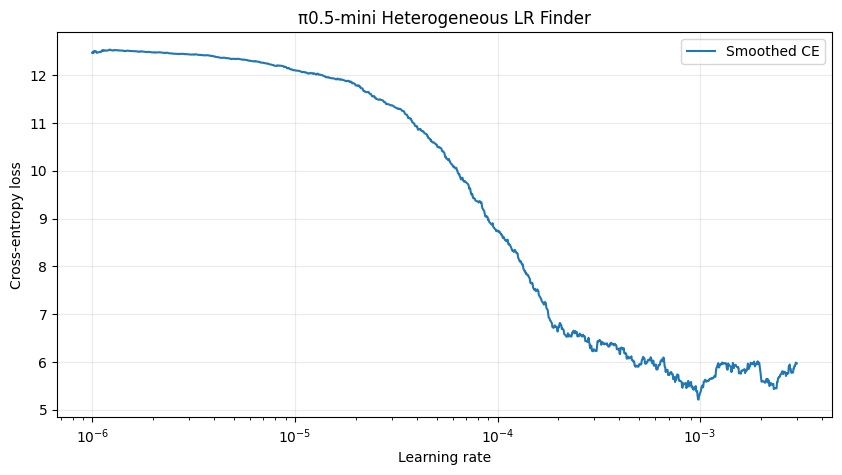

step    1 | lr=1.00e-06 | loss= 12.4693 | smooth= 12.4693 | grad=   3.697 |  0.12 steps/s
step   50 | lr=1.30e-06 | loss= 12.4212 | smooth= 12.5266 | grad=   4.171 |  5.06 steps/s
step  100 | lr=1.70e-06 | loss= 12.3289 | smooth= 12.4923 | grad=   8.493 |  8.58 steps/s
step  150 | lr=2.22e-06 | loss= 12.4445 | smooth= 12.4733 | grad=  10.297 | 11.31 steps/s
step  200 | lr=2.89e-06 | loss= 12.5875 | smooth= 12.4432 | grad=   6.933 | 13.49 steps/s
step  250 | lr=3.78e-06 | loss= 12.3079 | smooth= 12.4117 | grad=   4.039 | 15.23 steps/s
step  300 | lr=4.94e-06 | loss= 12.2821 | smooth= 12.3425 | grad=   4.279 | 15.67 steps/s
step  350 | lr=6.45e-06 | loss= 12.1215 | smooth= 12.2900 | grad=   4.251 | 16.24 steps/s
step  400 | lr=8.42e-06 | loss= 11.9422 | smooth= 12.1965 | grad=   4.336 | 17.29 steps/s
step  450 | lr=1.10e-05 | loss= 12.4248 | smooth= 12.0701 | grad=  11.861 | 17.00 steps/s
step  500 | lr=1.44e-05 | loss= 12.0749 | smooth= 11.9584 | grad=  19.822 | 17.81 steps/s
step  550 

step  600 | lr=2.45e-05 | loss= 11.3917 | smooth= 11.5602 | grad=   2.906 | 19.23 steps/s
step  650 | lr=3.20e-05 | loss= 11.0760 | smooth= 11.3073 | grad=   2.876 | 19.86 steps/s
step  700 | lr=4.18e-05 | loss= 10.4829 | smooth= 10.8650 | grad=   4.474 | 20.42 steps/s
step  750 | lr=5.46e-05 | loss=  9.9484 | smooth= 10.3767 | grad=   2.573 | 20.96 steps/s


step  800 | lr=7.13e-05 | loss=  9.3731 | smooth=  9.7267 | grad=   2.622 | 21.41 steps/s
step  850 | lr=9.32e-05 | loss=  8.3516 | smooth=  8.8793 | grad=   2.410 | 21.75 steps/s
step  900 | lr=1.22e-04 | loss=  9.2930 | smooth=  8.3430 | grad=   4.338 | 22.11 steps/s
step  950 | lr=1.59e-04 | loss=  7.1420 | smooth=  7.4895 | grad=  12.679 | 22.18 steps/s
step 1000 | lr=2.08e-04 | loss=  2.9207 | smooth=  6.6867 | grad=  14.827 | 22.56 steps/s


step 1050 | lr=2.71e-04 | loss=  1.8397 | smooth=  6.4340 | grad=  11.393 | 22.42 steps/s
step 1100 | lr=3.54e-04 | loss=  6.4270 | smooth=  6.3206 | grad=   2.469 | 22.72 steps/s
step 1150 | lr=4.63e-04 | loss=  5.7359 | smooth=  6.0336 | grad=   2.938 | 22.99 steps/s
step 1200 | lr=6.04e-04 | loss=  7.0020 | smooth=  5.9455 | grad=   5.055 | 22.62 steps/s
step 1250 | lr=7.89e-04 | loss=  5.2948 | smooth=  5.6051 | grad=   2.547 | 22.89 steps/s
step 1300 | lr=1.03e-03 | loss=  3.5275 | smooth=  5.4635 | grad=   4.542 | 23.09 steps/s
step 1350 | lr=1.35e-03 | loss=  5.3794 | smooth=  5.9582 | grad=   7.442 | 23.29 steps/s


step 1400 | lr=1.76e-03 | loss=  5.7326 | smooth=  5.9013 | grad=   4.060 | 23.50 steps/s
step 1450 | lr=2.30e-03 | loss=  5.4828 | smooth=  5.5384 | grad=   3.315 | 23.71 steps/s
step 1500 | lr=3.00e-03 | loss=  5.7944 | smooth=  5.9685 | grad=   7.278 | 23.94 steps/s

========== LR FINDER RESULT ==========
completed steps: 1500
lowest smoothed CE: 5.20909
LR at minimum loss: 9.825e-04
LR at steepest descent: 6.653e-04

Interpretation:

    steepest-descent LR
        = where learning accelerates most strongly

    minimum-loss LR
        = usually near the aggressive edge

Do NOT automatically choose the exact minimum.

We normally choose somewhere in the strong downward region
before the curve bottoms out / destabilizes.

========== REAL MODEL STATE ==========

train_params:
    UNCHANGED by LR finder

train_opt_state:
    UNCHANGED by LR finder

The LR finder trained only:
    lr_params
    lr_opt_state



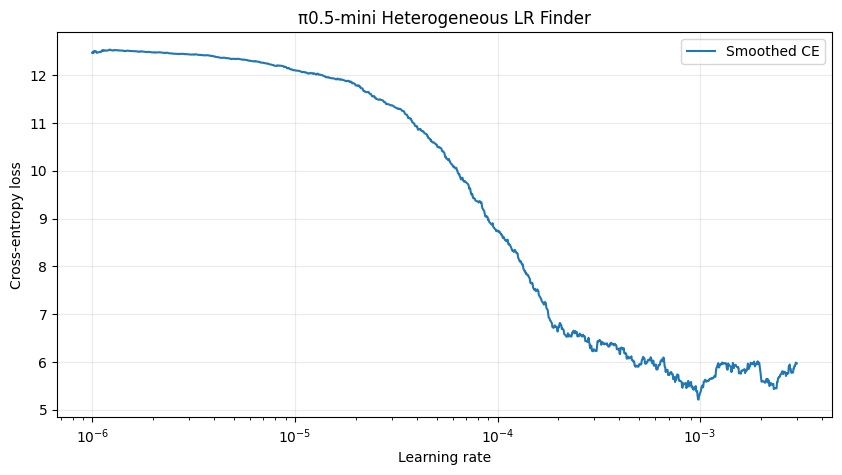

In [35]:
# Cell 13.5 finder — Learning Rate Finder
#
# Purpose:
# Find a useful learning-rate range for the SAME:
#
#   69.7M model
#   heterogeneous dataset mixture
#   batch size 1
#   AdamW optimizer
#
# IMPORTANT:
# This creates TEMPORARY fresh model parameters.
#
# It DOES NOT modify:
#   train_params
#   train_opt_state
#
# So our current trained model is safe.

import time

import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt

from IPython.display import display
from flax.core import freeze, unfreeze
import flax.traverse_util as traverse_util


# ============================================================
# 1. LR finder configuration
# ============================================================

LR_MIN = 1e-6
LR_MAX = 3e-3

LR_FINDER_STEPS = 1500

SMOOTH_BETA = 0.98

LOG_EVERY = 50


print("========== LR FINDER ==========")

print("minimum LR:", LR_MIN)
print("maximum LR:", LR_MAX)
print("steps:", LR_FINDER_STEPS)
print("batch size: 1")


# ============================================================
# 2. Create FRESH temporary parameters
#
# Same initialization recipe as Cell 12.
# This does NOT touch train_params.
# ============================================================

print("\nCreating fresh temporary 69.7M model...")


lr_variables = mini_model.init(
    jax.random.key(42),

    init_batch["base_image"],
    init_batch["image_1"],
    init_batch["image_2"],

    init_batch["image_slot_mask"],

    init_batch["tokens"],
    init_batch["token_mask"],
    init_batch["token_ar_mask"],
)


# ------------------------------------------------------------
# Randomize token embedding exactly like Cell 12
# ------------------------------------------------------------

mutable_lr_variables = unfreeze(
    lr_variables
)

flat_lr_params = traverse_util.flatten_dict(
    mutable_lr_variables["params"]
)

embedding_paths = [
    path
    for path in flat_lr_params
    if path[-1] == "input_embedding"
]

assert len(embedding_paths) == 1

embedding_path = embedding_paths[0]

embedding = flat_lr_params[
    embedding_path
]

flat_lr_params[embedding_path] = (
    jax.random.normal(
        jax.random.key(1234),
        embedding.shape,
        dtype=jnp.float32,
    )
    * 0.02
)

mutable_lr_variables["params"] = (
    traverse_util.unflatten_dict(
        flat_lr_params
    )
)

lr_variables = freeze(
    mutable_lr_variables
)

lr_params = lr_variables["params"]


print("fresh LR-finder parameters created")


# ============================================================
# 3. Exponential LR schedule
#
# LR increases smoothly:
#
# 1e-6
#   ↓
# ...
#   ↓
# 3e-3
# ============================================================

log_lr_ratio = jnp.log(
    LR_MAX / LR_MIN
)


def lr_schedule(count):

    fraction = (
        count.astype(jnp.float32)
        /
        float(LR_FINDER_STEPS - 1)
    )

    fraction = jnp.clip(
        fraction,
        0.0,
        1.0,
    )

    return (
        LR_MIN
        *
        jnp.exp(
            log_lr_ratio
            * fraction
        )
    )


# ============================================================
# 4. Same optimizer recipe as real training
# ============================================================

lr_optimizer = optax.chain(

    optax.clip_by_global_norm(
        1.0
    ),

    optax.adamw(
        learning_rate=lr_schedule,

        b1=0.9,
        b2=0.95,
        eps=1e-8,

        weight_decay=1e-10,
    ),
)


lr_opt_state = lr_optimizer.init(
    lr_params
)


# ============================================================
# 5. Compiled LR-finder training step
# ============================================================

def _lr_finder_step(
    params,
    opt_state,
    batch,
):

    loss, grads = jax.value_and_grad(
        loss_from_params
    )(
        params,
        batch,
    )

    grad_norm = optax.global_norm(
        grads
    )

    updates, new_opt_state = (
        lr_optimizer.update(
            grads,
            opt_state,
            params,
        )
    )

    new_params = optax.apply_updates(
        params,
        updates,
    )

    return (
        new_params,
        new_opt_state,
        loss,
        grad_norm,
    )


lr_finder_step = jax.jit(
    _lr_finder_step,

    # Temporary model: safe to donate buffers.
    donate_argnums=(0, 1),
)


# ============================================================
# 6. Independent prefetcher
#
# This keeps the LR finder separate from the sampler used
# by the real training run.
# ============================================================

lr_prefetcher = HeterogeneousPrefetcher(
    num_workers=32,
    prefetch=64,
    seed=8675309,
)


# ============================================================
# 7. Live LR-finder graph
# ============================================================

finder_lrs = []
finder_raw_losses = []
finder_smooth_losses = []
finder_grad_norms = []


fig, ax = plt.subplots(
    figsize=(10, 5)
)

finder_line, = ax.plot(
    [],
    [],
    label="Smoothed CE",
)

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "Learning rate"
)

ax.set_ylabel(
    "Cross-entropy loss"
)

ax.set_title(
    "π0.5-mini Heterogeneous LR Finder"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

live_lr_display = display(
    fig,
    display_id=True,
)


# ============================================================
# 8. Run LR range test
# ============================================================

ema_loss = 0.0
best_smooth_loss = float("inf")

finder_start = time.perf_counter()

completed_steps = 0


for step in range(
    1,
    LR_FINDER_STEPS + 1,
):

    # --------------------------------------------------------
    # Learning rate associated with THIS update.
    # --------------------------------------------------------

    fraction = (
        (step - 1)
        /
        (LR_FINDER_STEPS - 1)
    )

    current_lr = (
        LR_MIN
        *
        np.exp(
            np.log(
                LR_MAX / LR_MIN
            )
            * fraction
        )
    )


    # --------------------------------------------------------
    # Mixed real training example
    # --------------------------------------------------------

    example = lr_prefetcher.next()

    batch = make_jax_batch(
        example
    )


    # --------------------------------------------------------
    # REAL temporary training step
    # --------------------------------------------------------

    (
        lr_params,
        lr_opt_state,
        loss,
        grad_norm,
    ) = lr_finder_step(
        lr_params,
        lr_opt_state,
        batch,
    )


    loss, grad_norm = jax.block_until_ready(
        (
            loss,
            grad_norm,
        )
    )

    loss_value = float(loss)
    grad_value = float(grad_norm)


    if not np.isfinite(loss_value):
        print(
            "\nLoss became non-finite."
        )
        break


    # --------------------------------------------------------
    # Exponential moving-average smoothing
    # --------------------------------------------------------

    ema_loss = (
        SMOOTH_BETA * ema_loss
        +
        (1.0 - SMOOTH_BETA)
        * loss_value
    )


    # Bias correction.
    smooth_loss = (
        ema_loss
        /
        (
            1.0
            - SMOOTH_BETA ** step
        )
    )


    finder_lrs.append(
        current_lr
    )

    finder_raw_losses.append(
        loss_value
    )

    finder_smooth_losses.append(
        smooth_loss
    )

    finder_grad_norms.append(
        grad_value
    )


    completed_steps = step


    if smooth_loss < best_smooth_loss:

        best_smooth_loss = (
            smooth_loss
        )


    # --------------------------------------------------------
    # Stop once we've clearly passed into divergence.
    #
    # Ignore the first 100 steps because early estimates
    # are naturally noisy.
    # --------------------------------------------------------

    if (
        step > 100
        and smooth_loss
        > best_smooth_loss * 1.5
    ):

        print(
            "\nStopping early: "
            "loss has clearly diverged."
        )

        break


    # --------------------------------------------------------
    # Update graph / log
    # --------------------------------------------------------

    if (
        step == 1
        or step % LOG_EVERY == 0
    ):

        finder_line.set_data(
            finder_lrs,
            finder_smooth_losses,
        )

        ax.relim()
        ax.autoscale_view()

        live_lr_display.update(
            fig
        )


        elapsed = (
            time.perf_counter()
            - finder_start
        )

        print(
            f"step {step:4d} | "
            f"lr={current_lr:.2e} | "
            f"loss={loss_value:8.4f} | "
            f"smooth={smooth_loss:8.4f} | "
            f"grad={grad_value:8.3f} | "
            f"{step / elapsed:5.2f} steps/s"
        )


# ============================================================
# 9. Stop temporary workers
# ============================================================

lr_prefetcher.close()


# ============================================================
# 10. Final graph
# ============================================================

finder_line.set_data(
    finder_lrs,
    finder_smooth_losses,
)

ax.relim()
ax.autoscale_view()

live_lr_display.update(
    fig
)


# ============================================================
# 11. Diagnostics
# ============================================================

lr_array = np.asarray(
    finder_lrs
)

smooth_array = np.asarray(
    finder_smooth_losses
)


min_index = int(
    np.argmin(
        smooth_array
    )
)

minimum_loss_lr = (
    lr_array[min_index]
)

minimum_smooth_loss = (
    smooth_array[min_index]
)


# ------------------------------------------------------------
# Find the steepest downward section of the curve.
#
# Ignore the very beginning because initialization noise
# can dominate the numerical derivative.
# ------------------------------------------------------------

log_lr_array = np.log10(
    lr_array
)

slope = np.gradient(
    smooth_array,
    log_lr_array,
)

ignore = min(
    100,
    len(slope) // 5,
)

search_slice = slice(
    ignore,
    None,
)

steep_index = (
    np.argmin(
        slope[
            search_slice
        ]
    )
    + ignore
)

steepest_lr = (
    lr_array[
        steep_index
    ]
)


print(
    "\n========== LR FINDER RESULT =========="
)

print(
    "completed steps:",
    completed_steps,
)

print(
    "lowest smoothed CE:",
    f"{minimum_smooth_loss:.5f}",
)

print(
    "LR at minimum loss:",
    f"{minimum_loss_lr:.3e}",
)

print(
    "LR at steepest descent:",
    f"{steepest_lr:.3e}",
)


print("""
Interpretation:

    steepest-descent LR
        = where learning accelerates most strongly

    minimum-loss LR
        = usually near the aggressive edge

Do NOT automatically choose the exact minimum.

We normally choose somewhere in the strong downward region
before the curve bottoms out / destabilizes.
""")


# ============================================================
# 12. Explicit proof that real training state was untouched
# ============================================================

print(
    "========== REAL MODEL STATE =========="
)

print("""
train_params:
    UNCHANGED by LR finder

train_opt_state:
    UNCHANGED by LR finder

The LR finder trained only:
    lr_params
    lr_opt_state
""")

In [19]:
# Cell 14 — first REAL heterogeneous training updates
#
# Goal:
# Train the SAME fresh 69.7M model on the mixed:
#
#   ALOHA + DROID + COCO + VQAv2
#
# stream for 100 optimizer steps.
#
# This uses the SAME optimizer recipe as the prior
# ALOHA-only experiment.

import time
from collections import defaultdict

import jax
import jax.numpy as jnp
import numpy as np
import optax


# ============================================================
# 1. Same optimizer as previous experiment
# ============================================================

LEARNING_RATE = 1e-4

optimizer = optax.chain(

    optax.clip_by_global_norm(
        1.0
    ),

    optax.adamw(
        learning_rate=LEARNING_RATE,
        b1=0.9,
        b2=0.95,
        eps=1e-8,

        # Same effectively-zero weight decay as before.
        weight_decay=1e-10,
    ),
)


print("========== OPTIMIZER ==========")

print("optimizer:          AdamW")
print("learning rate:      ", LEARNING_RATE)
print("beta1:              ", 0.9)
print("beta2:              ", 0.95)
print("eps:                ", 1e-8)
print("gradient clipping:  ", 1.0)
print("weight decay:       ", 1e-10)


# ============================================================
# 2. Start from Cell 12's FRESH model parameters
# ============================================================

train_params = mini_variables["params"]

train_opt_state = optimizer.init(
    train_params
)

print(
    "\nOptimizer state initialized for "
    "the fresh heterogeneous model."
)


# ============================================================
# 3. One compiled optimizer step
# ============================================================

def _train_step(
    params,
    opt_state,
    batch,
):

    # loss_from_params() was defined in Cell 12.
    loss, grads = jax.value_and_grad(
        loss_from_params
    )(
        params,
        batch,
    )


    # Measure gradient magnitude BEFORE clipping.
    grad_norm = optax.global_norm(
        grads
    )


    updates, new_opt_state = optimizer.update(
        grads,
        opt_state,
        params,
    )


    new_params = optax.apply_updates(
        params,
        updates,
    )


    update_norm = optax.global_norm(
        updates
    )


    return (
        new_params,
        new_opt_state,
        loss,
        grad_norm,
        update_norm,
    )


# Donate the old parameter / optimizer buffers after every
# step to reduce peak device-memory pressure.
train_step = jax.jit(
    _train_step,
    donate_argnums=(0, 1),
)


# ============================================================
# 4. Burn-in configuration
# ============================================================

BURN_IN_STEPS = 100
LOG_EVERY = 10


source_losses = defaultdict(
    list
)

source_counts = defaultdict(
    int
)

all_losses = []
all_grad_norms = []
all_update_norms = []


print(
    "\n========== 100-STEP HETEROGENEOUS BURN-IN =========="
)

print(
    "The first step may be slow because JAX compiles "
    "the optimizer/backward graph."
)


# ============================================================
# 5. Train
# ============================================================

start_time = time.perf_counter()


for step in range(1, BURN_IN_STEPS + 1):

    # --------------------------------------------------------
    # CPU workers have already prepared this example.
    # --------------------------------------------------------

    example = train_prefetcher.next()

    source = example["source"]


    # --------------------------------------------------------
    # Transfer fixed-shape tensors to JAX/GPU.
    # --------------------------------------------------------

    batch = make_jax_batch(
        example
    )


    # --------------------------------------------------------
    # REAL forward + backward + optimizer update
    # --------------------------------------------------------

    (
        train_params,
        train_opt_state,
        loss,
        grad_norm,
        update_norm,
    ) = train_step(
        train_params,
        train_opt_state,
        batch,
    )


    # Only synchronize the small scalar results.
    (
        loss,
        grad_norm,
        update_norm,
    ) = jax.block_until_ready(
        (
            loss,
            grad_norm,
            update_norm,
        )
    )


    loss_value = float(
        loss
    )

    grad_value = float(
        grad_norm
    )

    update_value = float(
        update_norm
    )


    assert np.isfinite(
        loss_value
    )

    assert np.isfinite(
        grad_value
    )


    # --------------------------------------------------------
    # Logging
    # --------------------------------------------------------

    source_losses[source].append(
        loss_value
    )

    source_counts[source] += 1

    all_losses.append(
        loss_value
    )

    all_grad_norms.append(
        grad_value
    )

    all_update_norms.append(
        update_value
    )


    if (
        step == 1
        or step % LOG_EVERY == 0
    ):

        elapsed = (
            time.perf_counter()
            - start_time
        )

        # Exclude most compilation distortion once possible.
        steps_per_sec = (
            step / elapsed
        )

        recent_loss = np.mean(
            all_losses[
                -min(
                    LOG_EVERY,
                    len(all_losses),
                ):
            ]
        )

        print(
            f"step {step:3d} | "
            f"source={source:8s} | "
            f"loss={loss_value:8.4f} | "
            f"recent={recent_loss:8.4f} | "
            f"grad={grad_value:8.3f} | "
            f"{steps_per_sec:5.2f} steps/s"
        )


# ============================================================
# 6. Synchronize final parameter tree
# ============================================================

jax.tree.map(
    lambda x: x.block_until_ready(),
    train_params,
)


total_time = (
    time.perf_counter()
    - start_time
)


# ============================================================
# 7. Burn-in summary
# ============================================================

print(
    "\n========== BURN-IN SUMMARY =========="
)

print(
    "training steps:",
    BURN_IN_STEPS,
)

print(
    "elapsed:",
    f"{total_time:.2f} s",
)

print(
    "average throughput:",
    f"{BURN_IN_STEPS / total_time:.3f} steps/s",
)

print(
    "overall mean CE:",
    f"{np.mean(all_losses):.5f}",
)

print(
    "last 10-step CE:",
    f"{np.mean(all_losses[-10:]):.5f}",
)

print(
    "mean grad norm:",
    f"{np.mean(all_grad_norms):.5f}",
)


print(
    "\n========== PER-SOURCE TRAINING CE =========="
)

for source in sources:

    values = source_losses[source]

    if values:

        print(
            f"{source:8s} "
            f"steps={len(values):3d}  "
            f"mean={np.mean(values):8.5f}  "
            f"last={values[-1]:8.5f}"
        )

    else:

        print(
            f"{source:8s} "
            "steps=0"
        )


print(
    "\n========== SOURCE COUNTS =========="
)

for source in sources:

    print(
        f"{source:8s}:",
        source_counts[source],
    )


# ============================================================
# 8. Make trained state the current model state
# ============================================================

from flax.core import freeze, unfreeze

mutable_variables = unfreeze(
    mini_variables
)

mutable_variables["params"] = (
    train_params
)

mini_variables = freeze(
    mutable_variables
)


print(
    "\n========== STATUS =========="
)

print("""
The model has now REALLY been trained.

fresh 69.7M initialization
        ↓
100 mixed optimizer updates
        ↓
same parameters learned from:
    ALOHA
    DROID
    COCO
    VQAv2

The optimizer state is preserved in:

    train_opt_state

and the current trained parameters are:

    train_params

Do NOT reinitialize either before continuing to 10k steps.
""")

========== OPTIMIZER ==========
optimizer:          AdamW
learning rate:       0.0001
beta1:               0.9
beta2:               0.95
eps:                 1e-08
gradient clipping:   1.0
weight decay:        1e-10

Optimizer state initialized for the fresh heterogeneous model.

========== 100-STEP HETEROGENEOUS BURN-IN ==========
The first step may be slow because JAX compiles the optimizer/backward graph.
step   1 | source=aloha    | loss= 12.5595 | recent= 12.5595 | grad=   4.181 |  0.14 steps/s
step  10 | source=coco     | loss= 12.4301 | recent= 12.4212 | grad=  10.331 |  1.32 steps/s


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

step  20 | source=aloha    | loss= 12.0482 | recent= 12.1021 | grad=   4.412 |  2.51 steps/s


Generating train split: 0 examples [00:00, ? examples/s]

step  30 | source=vqav2    | loss= 10.9224 | recent= 11.6899 | grad=  13.666 |  3.59 steps/s


Generating train split: 0 examples [00:00, ? examples/s]

step  40 | source=droid    | loss= 11.6357 | recent= 11.7889 | grad=   2.223 |  4.34 steps/s
step  50 | source=vqav2    | loss= 11.0061 | recent= 11.2055 | grad=  21.701 |  5.25 steps/s
step  60 | source=vqav2    | loss= 10.1704 | recent= 11.2585 | grad=  12.541 |  6.09 steps/s
step  70 | source=aloha    | loss= 10.9245 | recent= 11.0207 | grad=   2.880 |  6.88 steps/s
step  80 | source=droid    | loss= 10.8078 | recent= 11.0344 | grad=   2.910 |  7.54 steps/s
step  90 | source=coco     | loss= 10.8352 | recent= 10.5833 | grad=   7.218 |  8.24 steps/s
step 100 | source=aloha    | loss= 10.2084 | recent= 10.1129 | grad=   2.512 |  8.93 steps/s

========== BURN-IN SUMMARY ==========
training steps: 100
elapsed: 11.21 s
average throughput: 8.921 steps/s
overall mean CE: 11.32177
last 10-step CE: 10.11291
mean grad norm: 7.19975

========== PER-SOURCE TRAINING CE ==========
aloha    steps= 25  mean=11.59125  last=10.20836
droid    steps= 28  mean=11.30099  last= 9.79939
coco     steps= 17 

========== HETEROGENEOUS PRETRAINING ==========
completed steps:     57300
target total steps:  200000
remaining updates:   142700

Continuing:
  existing train_params
  existing train_opt_state
  existing loss history
  NO model reinitialization
  NO optimizer reinitialization


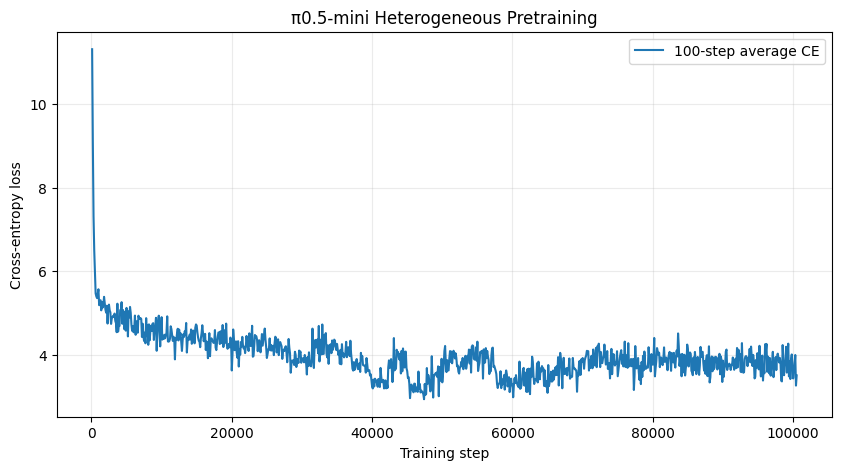

step  57400 | source=aloha    | loss=  2.8128 | avg100=  3.7334 | grad=  13.997 | 22.64 steps/s
step  57500 | source=droid    | loss=  4.0869 | avg100=  3.6765 | grad=   8.197 | 26.63 steps/s
step  57600 | source=droid    | loss=  3.7022 | avg100=  3.6186 | grad=   7.894 | 28.53 steps/s
step  57700 | source=vqav2    | loss=  1.6103 | avg100=  3.5367 | grad= 159.236 | 29.58 steps/s
step  57800 | source=coco     | loss=  5.8319 | avg100=  3.3000 | grad=  16.270 | 30.02 steps/s
step  57900 | source=droid    | loss=  2.3627 | avg100=  3.2011 | grad=  10.985 | 30.49 steps/s
step  58000 | source=coco     | loss=  4.5851 | avg100=  3.2832 | grad=  15.042 | 30.09 steps/s
step  58100 | source=coco     | loss=  2.1036 | avg100=  3.3061 | grad=  11.864 | 30.33 steps/s
step  58200 | source=coco     | loss=  4.0438 | avg100=  3.3485 | grad=  20.345 | 30.52 steps/s
step  58300 | source=coco     | loss=  6.4683 | avg100=  3.6038 | grad=  22.032 | 29.61 steps/s
step  58400 | source=vqav2    | loss=  2

KeyboardInterrupt: 

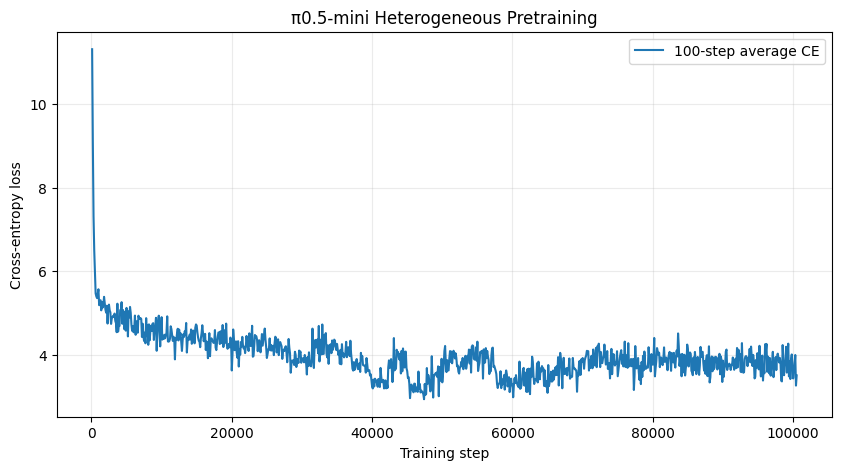

In [34]:
# Cell 15 — 200K heterogeneous π0.5-mini pretraining
#
# RESUME SAFE
#
# Continues the EXISTING:
#     train_params
#     train_opt_state
#     all_losses
#     source_losses
#
# Does NOT initialize the model or optimizer again.
#
# Live graph:
#     ONE line only
#     100-step rolling average CE

import time
from collections import deque

import jax
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from flax.core import freeze, unfreeze


# ============================================================
# 1. Configuration
# ============================================================

TOTAL_TRAIN_STEPS = 200_000

LOG_EVERY = 100
ROLLING_WINDOW = 100


# ============================================================
# 2. Resume from current training state
# ============================================================

START_STEP = len(all_losses)

assert START_STEP <= TOTAL_TRAIN_STEPS

print("========== HETEROGENEOUS PRETRAINING ==========")

print("completed steps:    ", START_STEP)
print("target total steps: ", TOTAL_TRAIN_STEPS)
print("remaining updates:  ", TOTAL_TRAIN_STEPS - START_STEP)

print("\nContinuing:")
print("  existing train_params")
print("  existing train_opt_state")
print("  existing loss history")
print("  NO model reinitialization")
print("  NO optimizer reinitialization")


# ============================================================
# 3. Restore rolling-loss window
# ============================================================

loss_window = deque(
    all_losses[-ROLLING_WINDOW:],
    maxlen=ROLLING_WINDOW,
)


# ============================================================
# 4. Reconstruct graph history
#
# If training was interrupted earlier, reconstruct the curve
# from all previously completed updates.
# ============================================================

plot_steps = []
plot_avg100 = []


for end_step in range(
    LOG_EVERY,
    START_STEP + 1,
    LOG_EVERY,
):

    begin_step = max(
        0,
        end_step - ROLLING_WINDOW,
    )

    avg100 = np.mean(
        all_losses[
            begin_step:end_step
        ]
    )

    plot_steps.append(
        end_step
    )

    plot_avg100.append(
        avg100
    )


# ============================================================
# 5. Create LIVE graph
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

line100, = ax.plot(
    plot_steps,
    plot_avg100,
    label="100-step average CE",
)

ax.set_xlabel(
    "Training step"
)

ax.set_ylabel(
    "Cross-entropy loss"
)

ax.set_title(
    "π0.5-mini Heterogeneous Pretraining"
)

ax.legend()

ax.grid(
    True,
    alpha=0.25,
)

if plot_steps:
    ax.relim()
    ax.autoscale_view()

live_display = display(
    fig,
    display_id=True,
)


# ============================================================
# 6. Training loop
# ============================================================

run_start = time.perf_counter()


for step in range(
    START_STEP + 1,
    TOTAL_TRAIN_STEPS + 1,
):

    # --------------------------------------------------------
    # Prefetched heterogeneous example
    # --------------------------------------------------------

    example = train_prefetcher.next()

    source = example["source"]


    # --------------------------------------------------------
    # Fixed-shape JAX batch
    # --------------------------------------------------------

    batch = make_jax_batch(
        example
    )


    # --------------------------------------------------------
    # REAL TRAINING STEP
    #
    # forward
    #   ↓
    # cross entropy
    #   ↓
    # backward
    #   ↓
    # gradient clipping
    #   ↓
    # AdamW
    #   ↓
    # updated parameters
    # --------------------------------------------------------

    (
        train_params,
        train_opt_state,
        loss,
        grad_norm,
        update_norm,
    ) = train_step(
        train_params,
        train_opt_state,
        batch,
    )


    # --------------------------------------------------------
    # Synchronize logging scalars
    # --------------------------------------------------------

    (
        loss,
        grad_norm,
        update_norm,
    ) = jax.block_until_ready(
        (
            loss,
            grad_norm,
            update_norm,
        )
    )


    loss_value = float(loss)
    grad_value = float(grad_norm)
    update_value = float(update_norm)


    assert np.isfinite(loss_value)
    assert np.isfinite(grad_value)


    # --------------------------------------------------------
    # Record training history
    # --------------------------------------------------------

    all_losses.append(
        loss_value
    )

    all_grad_norms.append(
        grad_value
    )

    all_update_norms.append(
        update_value
    )


    source_losses[source].append(
        loss_value
    )

    source_counts[source] += 1


    loss_window.append(
        loss_value
    )


    # --------------------------------------------------------
    # Every 100 steps:
    #
    #   rolling CE
    #   graph update
    #   console status
    # --------------------------------------------------------

    if step % LOG_EVERY == 0:

        avg100 = float(
            np.mean(
                loss_window
            )
        )


        # ----------------------------------------------------
        # Update live graph
        # ----------------------------------------------------

        plot_steps.append(
            step
        )

        plot_avg100.append(
            avg100
        )


        line100.set_data(
            plot_steps,
            plot_avg100,
        )

        ax.relim()
        ax.autoscale_view()

        live_display.update(
            fig
        )


        # ----------------------------------------------------
        # Throughput for this invocation
        # ----------------------------------------------------

        elapsed = (
            time.perf_counter()
            - run_start
        )

        completed_this_run = (
            step - START_STEP
        )

        steps_per_sec = (
            completed_this_run
            / elapsed
        )


        print(
            f"step {step:6d} | "
            f"source={source:8s} | "
            f"loss={loss_value:8.4f} | "
            f"avg100={avg100:8.4f} | "
            f"grad={grad_value:8.3f} | "
            f"{steps_per_sec:5.2f} steps/s"
        )


# ============================================================
# 7. Synchronize final model state
# ============================================================

jax.tree.map(
    lambda x: x.block_until_ready(),
    train_params,
)


run_elapsed = (
    time.perf_counter()
    - run_start
)


# ============================================================
# 8. Update mini_variables
# ============================================================

mutable_variables = unfreeze(
    mini_variables
)

mutable_variables["params"] = (
    train_params
)

mini_variables = freeze(
    mutable_variables
)


# ============================================================
# 9. Final summary
# ============================================================

print(
    "\n========== 200K TRAINING SUMMARY =========="
)

print(
    "total optimizer steps:",
    len(all_losses),
)


if TOTAL_TRAIN_STEPS > START_STEP:

    print(
        "this run time:",
        f"{run_elapsed / 60:.2f} minutes",
    )

    print(
        "this run throughput:",
        f"{(TOTAL_TRAIN_STEPS - START_STEP) / run_elapsed:.2f} steps/s",
    )


print(
    "\nfinal rolling CE:"
)

print(
    "last 100-step average:",
    f"{np.mean(all_losses[-100:]):.5f}",
)


# ============================================================
# 10. Per-source training results
# ============================================================

print(
    "\n========== PER-SOURCE TRAINING CE =========="
)

for source in sources:

    values = source_losses[source]

    recent_count = min(
        100,
        len(values),
    )

    print(
        f"{source:8s} "
        f"steps={len(values):6d} | "
        f"overall_mean={np.mean(values):8.5f} | "
        f"last100={np.mean(values[-recent_count:]):8.5f}"
    )


print(
    "\n========== SOURCE COUNTS =========="
)

for source in sources:

    print(
        f"{source:8s}:",
        source_counts[source],
    )


# ============================================================
# 11. Keep final graph visible
# ============================================================

live_display.update(
    fig
)


print(
    "\n========== STATUS =========="
)

print("""
200,000 heterogeneous optimizer updates completed.

Same fully-trainable 69.7M model learned jointly from:

    ALOHA
        → FAST robot-action tokens

    DROID
        → FAST robot-action tokens

    COCO
        → caption tokens

    VQAv2
        → answer tokens

Final parameters:
    train_params

Final optimizer state:
    train_opt_state

No LoRA.
No frozen backbone.
No model reinitialization.
""")